In [1]:
# Uncomment to install the required packages
#!pip install -U git+https://github.com/fagonzalezo/kdm.git@generative

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import gaussian_kde

import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import optimizers
from keras import losses
from keras import metrics
from keras.callbacks import ModelCheckpoint


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from kdm.models import KDMRegressModel
import kdm

from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
import torch
import torchvision.transforms as T
dinov2_vits14 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

dinov2_vits14.to(device)

transform_image = T.Compose([T.ToTensor(), T.Resize(244), T.CenterCrop(224), T.Normalize([0.5], [0.5])])

Using cache found in /Users/fgonza/.cache/torch/hub/facebookresearch_dinov2_main
/Users/fgonza/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/fgonza/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/fgonza/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


# 3 Generative image regression from binary labels

We train a generative image classifier based on KDM. The dataset is a synthetic image classifier available at https://www.kaggle.com/datasets/gonzalorecioc/color-polygon-images. The images in the dataset correspond to polygons with different sizes, locations and colors. The dataset can be used for different classification and regression tasks. Here we will address a regression task, to estimate the radius of the enclosing circle of the polygon. However, we will address it as a classification task to see if the learned prototypes are able to capture the continuos nature of the underlining problem.

In [3]:
# Download dataset
# https://www.kaggle.com/datasets/gonzalorecioc/color-polygon-images
# You have to upload your Kaggle api key: https://www.kaggle.com/docs/api#authentication

def get_polygon_dataset():
    ! pip install -q kaggle
    from google.colab import files
    files.upload()
    !mkdir ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("gonzalorecioc/color-polygon-images")
    return path

#path = get_polygon_dataset()

path = "./"
print("Path to dataset files:", path)

Path to dataset files: ./


In [4]:
# to run this example download the data from
# and set the paths accordingly
path = "/Users/fgonza/Documents/research/code/data/color_poly_images/"
targets_path = path + "/targets.csv"
images_path = path + "/images/content/images/"

In [5]:
print(targets_path)
print(images_path)

/Users/fgonza/Documents/research/code/data/color_poly_images//targets.csv
/Users/fgonza/Documents/research/code/data/color_poly_images//images/content/images/


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the targets.csv file
targets_df = pd.read_csv(targets_path)

targets_df.head()

In [7]:
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

class PolygonDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None):
        self.dataframe = dataframe
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Read the image path from targets_df
        row = self.dataframe.iloc[idx]
        file_name = row['filename']
        img_path = os.path.join(self.images_dir, file_name)
        # Open and convert image to RGB
        image = Image.open(img_path).convert("RGB")
        # Apply the given transforms
        if self.transform:
            image = self.transform(image)
        # Use 'bound_circle_r' as the target label (adjust if needed)
        target = row['bound_circle_r']
        return image, target

# Create the dataset
polygon_dataset = PolygonDataset(targets_df, images_path, transform=transform_image)

# Create the DataLoader
polygon_dataloader = DataLoader(polygon_dataset, batch_size=32, shuffle=False)

# Calculate the embedding for each image in polygon_dataloader
embeddings = []
for images, _ in tqdm(polygon_dataloader):
    images = images.to(device)
    with torch.no_grad():
        outputs = dinov2_vits14(images)
        embeddings.append(outputs.cpu().numpy())


  0%|          | 0/313 [00:00<?, ?it/s]/Users/fgonza/miniforge3/envs/tf2/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
100%|██████████| 313/313 [17:46<00:00,  3.41s/it]


In [10]:
emb_array = np.concatenate(embeddings, axis=0)
# add the embedings to the targets_df
targets_df['embedding'] = list(emb_array)
targets_df.head()

,Unnamed: 0,filename,sides,bg_color,fg_color,bound_circle_x,bound_circle_y,bound_circle_r,rotation,embedding
0,0,70aaa621-1345-4541-a954-ee9856daaf18.png,4,blue,pink,29,39,15,185,"[-0.5633571, 2.3609545, -0.46001595, -2.741356..."
1,1,ea0d8d14-596a-4365-b007-6325fc96e0f4.png,3,black,yellow,66,66,21,215,"[-3.0232553, 1.4725606, -2.8498416, -2.7854717..."
2,2,48c1fc5a-8b6b-4555-bb6a-a7d42a5cedc2.png,4,yellow,red,59,103,20,59,"[-1.1544101, -0.10021335, -1.0100248, -3.82071..."
3,3,ad721906-604c-4682-ae5d-15539ef1dbc7.png,3,green,pink,65,66,61,272,"[-2.1182013, 0.6241639, -1.9022398, -1.1412218..."
4,4,510dd5ea-fb92-432e-91cc-ed4654a03ebd.png,6,white,green,48,56,42,38,"[-2.6369035, 0.38315153, -2.6491406, -2.692691..."


In [11]:

# split the data into train and test
train_df, test_df = train_test_split(targets_df, test_size=0.2, random_state=42)

# Print the maximum and minumum values of bound_circle_r column
print(f"Maximum bound_circle_r: {train_df['bound_circle_r'].max()}")
print(f"Minimum bound_circle_r: {train_df['bound_circle_r'].min()}")

Maximum bound_circle_r: 66
Minimum bound_circle_r: 10


In [ ]:
train_df['embedding'].values

In [284]:
import tensorflow as tf
import pandas as pd

def create_tf_dataset(dataframe, target_column='rotation',
                      batch_size=32, image_folder_path='',
                      shuffle=True, add_noise=False):
    """
    Converts a Pandas DataFrame into a TensorFlow dataset for image classification.

    Args:
        dataframe (pd.DataFrame): The input DataFrame containing image filenames and target labels.
        target_column (str, optional): The column name in the DataFrame representing the target labels.
                                       Defaults to 'rotation'.
        batch_size (int, optional): The batch size for the dataset. Defaults to 32.
        image_folder_path (str, optional): The path to the folder containing the images. Defaults to ''.
        shuffle (bool, optional): Whether to shuffle the dataset. Defaults to True.

    Returns:
        tf.data.Dataset: A TensorFlow dataset with preprocessed images and corresponding labels.
                           Images are loaded, resized, and normalized.
                           Target labels are scaled to a range between 0.1 and 0.9.
    """
    # Drop the 'Unnamed: 0' column if it exists
    if 'Unnamed: 0' in dataframe.columns:
        dataframe = dataframe.drop(columns=['Unnamed: 0'])

    embeddings = dataframe['embedding'].values
    embeddings = np.array([np.array(x) for x in embeddings])
    target = dataframe[target_column].values / 70.# Normalize the target values
    # add noise
    if add_noise:
        target = target + np.random.normal(0, 0.1, target.shape)
        target = np.clip(target, 0, 1)

    # make target binary label
    target = (target > 0.5).astype(float)
    target = target.reshape(-1, 1)
    target = tf.cast(target, tf.float32)
    # make target a ohe
    #target = keras.utils.to_categorical(target, num_classes=2)
    #target = target[:,1:]

    # Scale the target to [0.1, 0.9]
    #target = (target - np.min(target)) / (np.max(target) - np.min(target)) * 0.8 + 0.1

    # Create a TensorFlow dataset from image paths and targets
    dataset = tf.data.Dataset.from_tensor_slices((embeddings, target))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))  # Shuffle if shuffle=True

    dataset = (dataset
                .batch(batch_size)
                .prefetch(buffer_size=tf.data.AUTOTUNE))

    return dataset

In [285]:
import tensorflow as tf

train_ds = create_tf_dataset(train_df, target_column='bound_circle_r',
                             batch_size=128, image_folder_path=images_path,
                             shuffle=True, add_noise=True)

test_ds = create_tf_dataset(test_df, target_column='bound_circle_r',
                            batch_size=32, image_folder_path=images_path,
                            shuffle=False, add_noise=False)


In [286]:
# prompt: For both train_ds and test_ds count the number of elements in each class

import numpy as np

# Assuming 'train_ds' and 'test_ds' are tf.data.Datasets
# Iterate through the datasets and count elements in each class
def count_class_elements(dataset):
    class_counts = {}
    for images, labels in dataset:
        for label in labels.numpy():
            class_idx = np.argmax(label) # Assuming one-hot encoding
            class_counts[class_idx] = class_counts.get(class_idx, 0) + 1
    return class_counts

train_class_counts = count_class_elements(train_ds)
test_class_counts = count_class_elements(test_ds)

print("Train Class Counts:", train_class_counts)
print("Test Class Counts:", test_class_counts)

Train Class Counts: {0: 8000}
Test Class Counts: {0: 2000}


2025-02-15 15:03:42.781833: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:03:42.792572: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


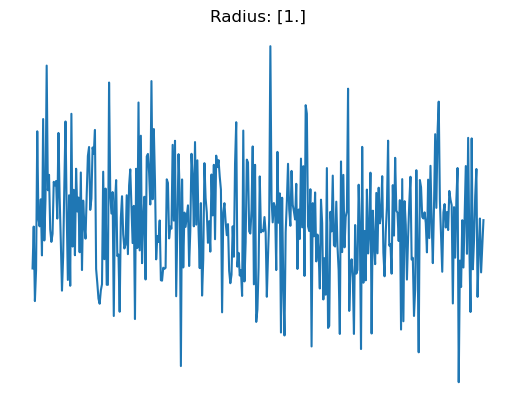

8.263375 -7.447738
(384,)


2025-02-15 15:03:43.001543: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [287]:
# read an image from the dataset and plot it
for image, label in train_ds.take(1):
    plt.plot(image[0].numpy())
    plt.title(f"Radius: {label[0].numpy()}")
    plt.axis('off')
    plt.show()
    print(np.max(image[0].numpy()), np.min(image[0].numpy()))
    print(image[0].shape)

In [420]:
def create_encoder(input_shape, layer_sizes):
    """
    Creates an encoder model.

    Args:
        input_shape (tuple): Shape of the encoder input.
        layer_sizes (list): List of integers specifying the hidden layer sizes. 
            The last element is the encoded size.
            If empty, a simple Identity model is returned.
    Returns:
        keras.Model: The encoder model.
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs
    if layer_sizes:
        for hidden_size in layer_sizes[:-1]:
            x = keras.layers.Dense(hidden_size, activation=keras.activations.gelu)(x)
        x = keras.layers.Dense(layer_sizes[-1])(x)
        #outputs = keras.layers.UnitNormalization(axis=-1)(x)
        outputs = x
        encoder = keras.Model(inputs, outputs, name="encoder")
    else:
        #encoder = keras.Sequential([keras.layers.UnitNormalization(axis=-1)])
        encoder = keras.Sequential([keras.layers.Identity()])
    return encoder


def train_disc_regress_model(input_shape,
                   layer_sizes=[],
                   wmp_epochs=0,
                   n_comp=64,
                   sigma_mult=1.0,
                   epochs=10,
                   batch_size=128,):

    if len(layer_sizes) == 0:
        encoded_size = input_shape[0]
    else:
        encoded_size = layer_sizes[-1]
    encoder = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
    print(encoder.summary())
    if wmp_epochs > 0:
        # warm up the encoder with a small subset
        encoder_wmp = keras.Sequential([encoder,
                                        keras.layers.Dense(1, activation='sigmoid')])
        encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                        loss=losses.binary_crossentropy,
                        metrics=[metrics.binary_accuracy])
        # train the encoder for 2 epoch
        subset_ds = train_ds
        encoder_wmp.fit(subset_ds, epochs=wmp_epochs, verbose=1)
    # Create a KDM classifier model
    kdm_disc = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=1,
                                encoder=encoder,
                                n_comp=n_comp,
                            sigma_x=0.2,
                            sigma_y=0.3,
                            min_sigma_y=0.15,
                            generative=0.,
                            sigma_x_trainable=True)

    # initialize the prototypes using random sample from train_ds
    init_prot_x = []
    init_prot_y = []
    for image, label in train_ds.unbatch().take(n_comp):
        init_prot_x.append(image[None, ...])
        init_prot_y.append(label)
    init_prot_x = np.concatenate(init_prot_x, axis=0)
    print(init_prot_x.shape)
    init_prot_y = np.array(init_prot_y)
    kdm_disc.init_components(init_prot_x, init_prot_y,
                            init_sigma=True, sigma_mult=sigma_mult)
    print(f"Sigma: {kdm_disc.kdm.kernel.sigma.numpy()}")
    # Compile the model
    kdm_disc.compile(optimizer=optimizers.Adam(learning_rate=1e-4))

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    #kdm_disc.predict(X_train[:10])
    history = kdm_disc.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)

    kdm_disc.load_weights('best_model.weights.h5')

    # Evaluate the classifier
    score = kdm_disc.evaluate(test_ds, verbose=0)
    # calculate accuracy
    y_pred, y_var = kdm_disc.predict_reg(test_ds)
    y_pred_class = (y_pred > 0.5).astype(int).flatten()
    y_test_class =  test_ds.map(lambda x, y: y).unbatch()
    y_test_class = np.concatenate([y for _, y in test_ds.unbatch()], axis=0)
    y_test_class = (y_test_class > 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_test_class)
    print(f"Test Accuracy: {accuracy}")
    print('Test loss:', score)
    print(f'Sigma x: {kdm_disc.kernel.sigma.numpy()}')
    print(f'Sigma y: {kdm_disc.sigma_y.numpy()}')

    return kdm_disc, history


In [421]:
input_shape=(384,)
layer_sizes=[32]
num_components = 128
kdm_disc_1, history = train_disc_regress_model(input_shape=input_shape,
                                   layer_sizes=layer_sizes,
                                   n_comp=128,
                                   sigma_mult=1.0,
                                   wmp_epochs=2,
                                   epochs=2,
                                   batch_size=128)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_165 (InputLayer)    │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 32)             │        12,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,320 (48.12 KB)

 Trainable params: 12,320 (48.12 KB)

 Non-trainable params: 0 (0.00 B)

...

2025-02-15 15:20:28.098847: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:28.233212: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


2025-02-15 15:20:28.339864: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:28.416761: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test Accuracy: 0.9695
Test loss: -0.5378864407539368
Sigma x: 6.398998260498047
Sigma y: 0.28730130195617676


2025-02-15 15:20:28.588324: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [422]:
def train_gen_regress_model(input_shape,
                   layer_sizes=[],
                   n_comp=64,
                   sigma_mult=0.2,
                   sigma_x_trainable=False,
                   epochs=20,
                   batch_size=128,
                   kdm_disc=None):
    if len(layer_sizes) == 0:
        encoded_size = input_shape[0]
    else:
        encoded_size = layer_sizes[-1]
        
    encoder = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
    encoder.set_weights(kdm_disc.encoder.get_weights())

    # Create a KDM classifier model
    kdm_gen = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=1,
                                encoder=encoder,
                                n_comp=n_comp,
                            sigma_x=kdm_disc.kernel.sigma.numpy() * sigma_mult,
                            sigma_y=0.3,
                            min_sigma_y=0.15,
                            generative=1.,
                            sigma_x_trainable=sigma_x_trainable)

    # initialize the prototypes using random sample from train_ds
    init_prot_x = []
    init_prot_y = []
    for image, label in train_ds.unbatch().take(n_comp):
        init_prot_x.append(image[None, ...])
        init_prot_y.append(label)
    init_prot_x = np.concatenate(init_prot_x, axis=0)
    print(init_prot_x.shape)
    init_prot_y = np.array(init_prot_y)
    kdm_gen.init_components(init_prot_x, init_prot_y,
                            init_sigma=False)
    print(f"Sigma: {kdm_gen.kdm.kernel.sigma.numpy()}")
    # Compile the model
    kdm_gen.compile(optimizer=optimizers.Adam(learning_rate=1e-3))

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model_gen.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    history = kdm_gen.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)

    kdm_gen.load_weights('best_model_gen.weights.h5')

    y_pred, y_var = kdm_gen.predict_reg(test_ds)
    y_pred_class = (y_pred > 0.5).astype(int).flatten()
    y_test_class = np.concatenate([y for _, y in test_ds.unbatch()], axis=0)
    y_test_class = (y_test_class > 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_test_class)

    # Evaluate the classifier
    score = kdm_gen.evaluate(test_ds, verbose=0)
    print('Test loss:', score)
    print('Test accuracy:', accuracy)
    sigma_x, sigma_y = kdm_gen.get_sigmas()
    print(f'Sigma_x: {sigma_x}')
    print(f'Sigma_y: {sigma_y}')

    return kdm_gen, history


In [423]:
num_components = 128
kdm_gen_1, history = train_gen_regress_model(input_shape=input_shape,
                                   layer_sizes=layer_sizes,
                                      sigma_mult=0.7,
                                      n_comp=num_components,
                                      epochs=20,
                                      batch_size=128,
                                      kdm_disc=kdm_disc_1)

(128, 384)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sigma: 4.4792985916137695
Epoch 1/20
 1/63 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 133.7438

2025-02-15 15:20:28.693227: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 133.5180 - val_loss: 133.1643
Epoch 2/20
16/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 133.1575 

2025-02-15 15:20:29.006985: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:29.106600: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 133.1190 - val_loss: 132.7084
Epoch 3/20
 7/63 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 132.7177

...

2025-02-15 15:20:36.280921: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:36.388677: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 132.0811 - val_loss: 131.9708
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


2025-02-15 15:20:36.716781: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:36.812716: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:36.910278: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test loss: 131.97076416015625
Test accuracy: 0.968
Sigma_x: 4.4792985916137695
Sigma_y: 0.15000000596046448


2025-02-15 15:20:37.069412: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:37.208847: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


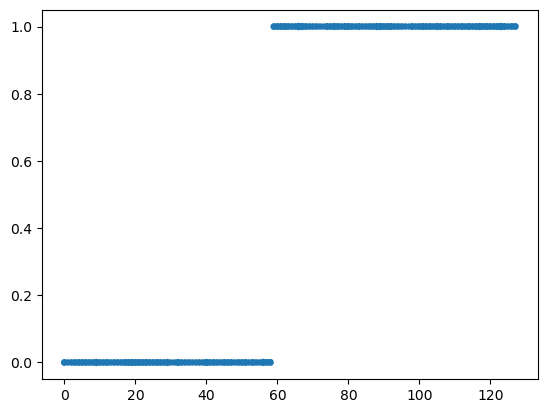

In [424]:
# plot y prototypes
xs = kdm_gen_1.kdm.c_x.numpy()
ys = kdm_gen_1.kdm.c_y.numpy()
weights = np.abs(kdm_gen_1.kdm.c_w.numpy())
weights /= np.sum(weights)


sorted_ys = ys.flatten()
idx = np.argsort(sorted_ys)


sorted_xs = xs[idx]
sorted_ys = sorted_ys[idx]
sorted_weights = weights[idx]


# create prototypes_df using sorted xs, ys and weights
prototypes_df = pd.DataFrame({'x': sorted_xs.tolist(),  'y':sorted_ys, 'w': sorted_weights})

plt.scatter(np.arange(len(prototypes_df['y'])),
            prototypes_df['y'], s=prototypes_df['w']*2000)

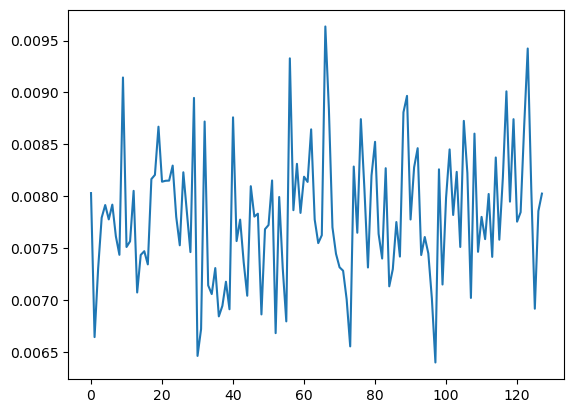

In [425]:
plt.plot(sorted_weights)

In [426]:
from kdm.utils import pure2dm
from kdm.utils import dm_rbf_expectation

def adjust_gen_model(input_shape,
                    layer_sizes=[],
                    kdm_gen=None):
    encoded_size = kdm_gen.encoded_size
    n_comp = kdm_gen.n_comp
    encoder = create_encoder(input_shape=input_shape,
                                   layer_sizes=layer_sizes)
    encoder.set_weights(kdm_gen.encoder.get_weights())
    sigma_x, sigma_y = kdm_gen.get_sigmas()

    # Create a KDM classifier model
    kdm_gen_adj = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=1,
                                encoder=encoder,
                                n_comp=n_comp,
                            sigma_x=sigma_x,
                            sigma_y=sigma_y,
                            min_sigma_y=sigma_y,
                            generative=1.,
                            sigma_x_trainable=False,
                            x_train=False,
                            y_train=False,
                            w_train=True)

    kdm_gen_adj.compile(optimizer=optimizers.Adam(learning_rate=5e-3))
    kdm_gen_adj.kdm.c_y.assign(kdm_gen.kdm.c_y)
    kdm_gen_adj.kdm.c_w.assign(kdm_gen.kdm.c_w)
    kdm_gen_adj.kdm.c_x.assign(kdm_gen.kdm.c_x)

    x_prot = kdm_gen.kdm.c_x
    rho_x = pure2dm(x_prot)
    rho_y = kdm_gen.kdm(rho_x)
    y_prot_pred = keras.ops.convert_to_numpy(dm_rbf_expectation(rho_y))
    kdm_gen_adj.kdm.c_y.assign(y_prot_pred)

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model_gen_adj.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    history=[]
    '''
    history = kdm_gen_adj.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)
    kdm_gen_adj.load_weights('best_model_gen_adj.weights.h5')
    '''

    y_pred, y_var = kdm_gen_adj.predict_reg(test_ds)
    y_pred_class = (y_pred > 0.5).astype(int).flatten()
    y_test_class = np.concatenate([y for _, y in test_ds.unbatch()], axis=0)
    y_test_class = (y_test_class > 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_test_class)
    print(f"Accuracy: {accuracy}")

    # Evaluate the classifier
    score = kdm_gen_adj.evaluate(test_ds, verbose=0)
    print('Test loss:', score)
    print('Test accuracy:', accuracy)
    print(f'Sigma x: {kdm_gen.kernel.sigma.numpy()}')
    print(f'Sigma y: {kdm_gen.sigma_y.numpy()}')

    return kdm_gen_adj, history


In [427]:
kdm_gen_adj, history = adjust_gen_model(input_shape=input_shape,
                                layer_sizes=layer_sizes,
                                kdm_gen=kdm_gen_1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.965


2025-02-15 15:20:37.526625: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:20:37.680352: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test loss: 132.40011596679688
Test accuracy: 0.965
Sigma x: 4.4792985916137695
Sigma y: 0.15000000596046448


2025-02-15 15:20:37.789851: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


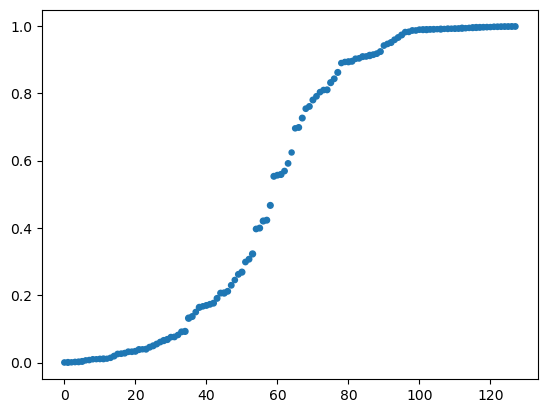

In [428]:
# plot y prototypes
xs = kdm_gen_adj.kdm.c_x.numpy()
ys = kdm_gen_adj.kdm.c_y.numpy()
weights = np.abs(kdm_gen_adj.kdm.c_w.numpy())
weights /= np.sum(weights)


sorted_ys = ys.flatten()
idx = np.argsort(sorted_ys)


sorted_xs = xs[idx]
sorted_ys = sorted_ys[idx]
sorted_weights = weights[idx]

plt.scatter(np.arange(len(sorted_xs)),
            sorted_ys, s=weights*2000)

# create prototypes_df
prototypes_df = pd.DataFrame({'x': xs.tolist(),  'y':ys.flatten(), 'w': weights})


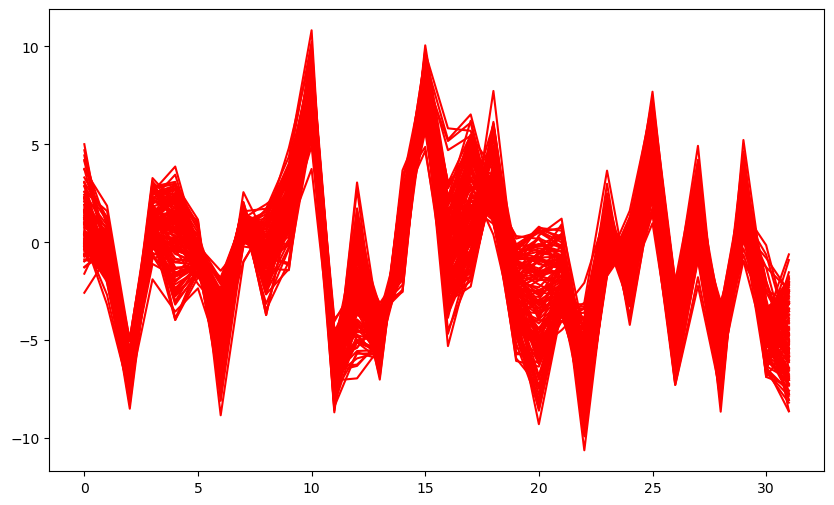

In [429]:
import matplotlib.pyplot as plt

# Assuming prototypes_df and train_df_encoded are defined as in your code

plt.figure(figsize=(10, 6))  # Adjust figure size as needed

for index, row in prototypes_df.iterrows():
    prototype_encoding = row['x']


    # Plot the prototype's encoding vector
    plt.plot(np.arange(len(prototype_encoding)), prototype_encoding, color='red', label='Prototype Encoding')
plt.show()

In [430]:
encoded_size = 384
encoder_1 = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
encoder_1.set_weights(kdm_disc_1.encoder.get_weights())

train_ds_noshuf = create_tf_dataset(train_df, target_column='bound_circle_r',
                             batch_size=128, image_folder_path=images_path,
                                    shuffle=False)



In [431]:
# prompt: Encode the images in train_ds_noshuf.
# Create a copy of train_df and add the encoding vector as a new column.

# Encode the images in train_ds_noshuf
encoded_images = encoder_1.predict(train_ds_noshuf)

# Create a copy of train_df
train_df_encoded = train_df.copy()

#reset indices
train_df_encoded.reset_index(drop=True, inplace=True)

# Add the encoding vector as a new column
train_df_encoded['encoding'] = encoded_images.tolist()

 1/63 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step


2025-02-15 15:20:38.139207: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [432]:
# prompt: Use sklearn to find the k-nearest neighbors of each prototype in prototypes_df. in encoded images.
# Store the indices of the nn as a list in a column of a  prototypes_df.

from sklearn.neighbors import NearestNeighbors

# Assuming 'prototypes_df' and 'encoded_images' are defined as in your provided code

# Create a NearestNeighbors model with k=5 (you can adjust k as needed)
knn_model = NearestNeighbors(n_neighbors=20)

# Fit the model on the encoded images
knn_model.fit(encoded_images)

# Find the k-nearest neighbors for each prototype in prototypes_df
prototype_encodings = np.array([x for x in prototypes_df['x'].values])
distances, indices = knn_model.kneighbors(prototype_encodings)

# Store the indices of the nearest neighbors as a list in a new column 'nn_indices'
prototypes_df['nn_indices'] = indices.tolist()

In [433]:
# prompt: For each prototype, calculate the average and std deviation of the bound_circle_r attribute of the nearest neighbors

# Assuming prototypes_df and train_df_encoded are defined as in your code

# Calculate average and std deviation of 'bound_circle_r' for nearest neighbors
prototypes_df['nn_bound_circle_r_avg'] = 0.0
prototypes_df['nn_bound_circle_r_std'] = 0.0

for index, row in prototypes_df.iterrows():
    nn_indices = row['nn_indices']
    nn_bound_circle_r = train_df_encoded.iloc[nn_indices]['bound_circle_r'].values
    prototypes_df.at[index, 'nn_bound_circle_r_avg'] = np.mean(nn_bound_circle_r)
    prototypes_df.at[index, 'nn_bound_circle_r_std'] = np.std(nn_bound_circle_r)

print(prototypes_df[['nn_bound_circle_r_avg', 'nn_bound_circle_r_std']])

     nn_bound_circle_r_avg  nn_bound_circle_r_std
0                    46.55               2.957617
1                    60.60               2.764055
2                    16.85               1.981792
3                    32.60               2.817801
4                    46.50               2.673948
..                     ...                    ...
123                  54.45               3.499643
124                  22.50               3.106445
125                  19.25               2.188036
126                  36.80               3.187475
127                  36.35               2.706936

[128 rows x 2 columns]


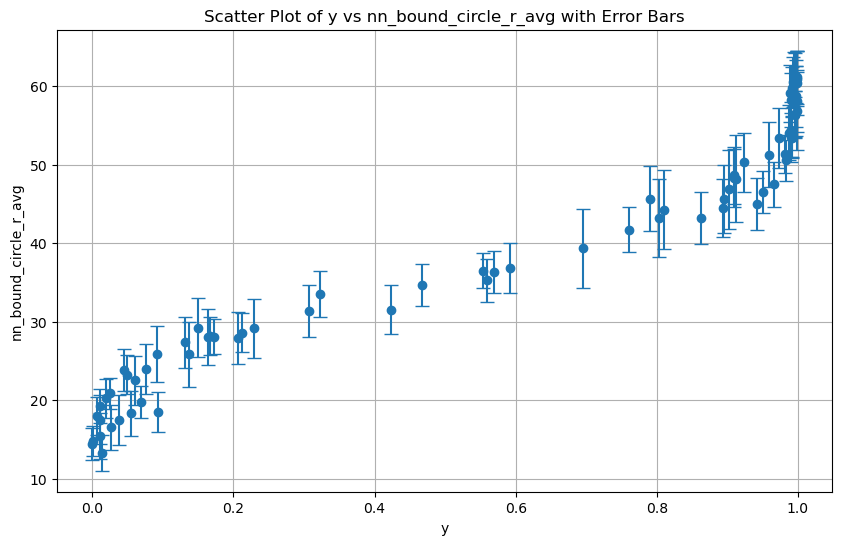

In [434]:
# prompt: Make a scatter plot of the y column vs nn_bound_circle_r_avg column using nn_bound_circle_r_std as error bars

# Calculate the 50th percentile of the 'w' column
percentile = prototypes_df['w'].quantile(0.4)

# Create a copy of prototypes_df with prototypes above the 50th percentile
prototypes_df_top = prototypes_df[prototypes_df['w'] >= percentile].copy()


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(prototypes_df_top['y'], prototypes_df_top['nn_bound_circle_r_avg'],
             yerr=prototypes_df_top['nn_bound_circle_r_std'], fmt='o', capsize=5)
plt.xlabel('y')
plt.ylabel('nn_bound_circle_r_avg')
plt.title('Scatter Plot of y vs nn_bound_circle_r_avg with Error Bars')
plt.grid(True)
plt.show()

Prototype 53:
- Weight: 0.009011016227304935
- y value: 0.9089034199714661
- nn_bound_circle_r_avg: 48.65
- nn_bound_circle_r_std: 3.6369630187836663


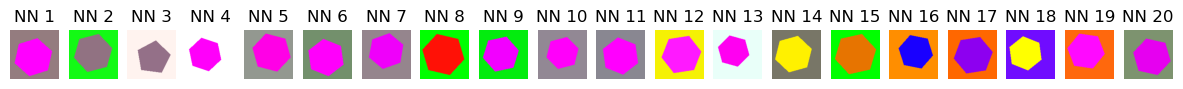

In [435]:
# prompt: for a particular prototype given by prot_idx (prototype index):
# - print its weight and y value
# - show the nn images using the image path in train_df_encoded

import matplotlib.pyplot as plt

# Assuming prototypes_df and train_df_encoded are defined as in your code

prot_idx = 53  # Replace with the desired prototype index

# Print the weight and y value for the specified prototype
print(f"Prototype {prot_idx}:")
print(f"- Weight: {prototypes_df['w'][prot_idx]}")
print(f"- y value: {prototypes_df['y'][prot_idx]}")
print(f"- nn_bound_circle_r_avg: {prototypes_df['nn_bound_circle_r_avg'][prot_idx]}")
print(f"- nn_bound_circle_r_std: {prototypes_df['nn_bound_circle_r_std'][prot_idx]}")

# Show the NN images
nn_indices = prototypes_df['nn_indices'][prot_idx]

plt.figure(figsize=(15, 5))  # Adjust figure size as needed

for i, img_idx in enumerate(nn_indices):
  img_path = images_path + "/" + train_df_encoded['filename'][img_idx]
  img = plt.imread(img_path)
  plt.subplot(1, len(nn_indices), i + 1)
  plt.imshow(img)
  plt.title(f"NN {i+1}")
  plt.axis('off')
plt.show()

Prototype 1:
- Weight: 0.008451594971120358
- y value: 0.9967459440231323
- nn_bound_circle_r_avg: 60.6
- nn_bound_circle_r_std: 2.764054992217051


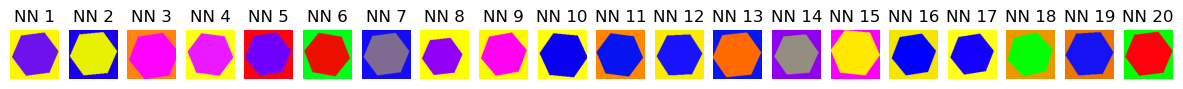

Prototype 17:
- Weight: 0.00781992357224226
- y value: 0.9962722063064575
- nn_bound_circle_r_avg: 61.4
- nn_bound_circle_r_std: 2.817800560721074


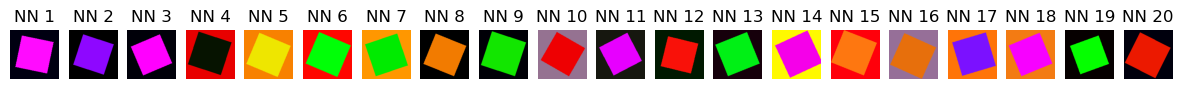

Prototype 25:
- Weight: 0.008278919383883476
- y value: 0.9917527437210083
- nn_bound_circle_r_avg: 59.85
- nn_bound_circle_r_std: 2.5743931323712004


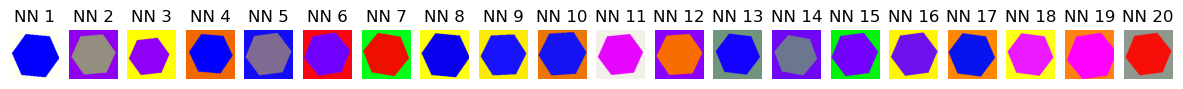

Prototype 31:
- Weight: 0.007751914672553539
- y value: 0.9982839226722717
- nn_bound_circle_r_avg: 61.0
- nn_bound_circle_r_std: 3.521363372331802


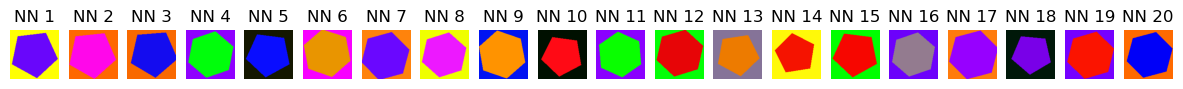

Prototype 38:
- Weight: 0.008726549334824085
- y value: 0.9590399861335754
- nn_bound_circle_r_avg: 51.3
- nn_bound_circle_r_std: 4.172529209005013


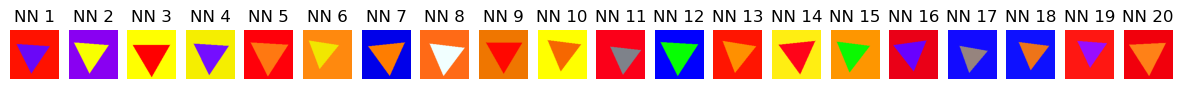

Prototype 44:
- Weight: 0.008025864139199257
- y value: 0.9982584714889526
- nn_bound_circle_r_avg: 56.85
- nn_bound_circle_r_std: 4.942418436352795


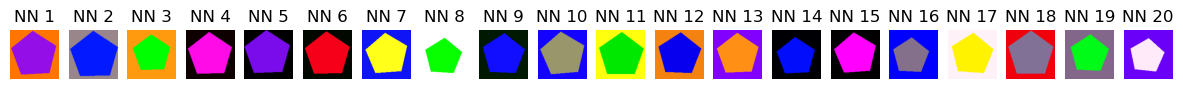

Prototype 50:
- Weight: 0.00874294899404049
- y value: 0.9984437227249146
- nn_bound_circle_r_avg: 58.15
- nn_bound_circle_r_std: 3.9404948927767944


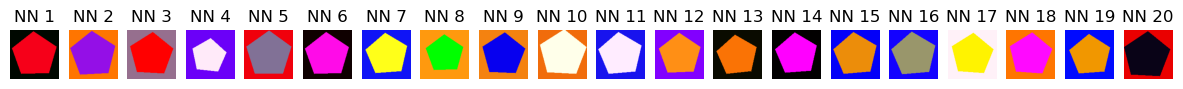

Prototype 57:
- Weight: 0.008206108585000038
- y value: 0.1639275997877121
- nn_bound_circle_r_avg: 28.0
- nn_bound_circle_r_std: 3.5637059362410923


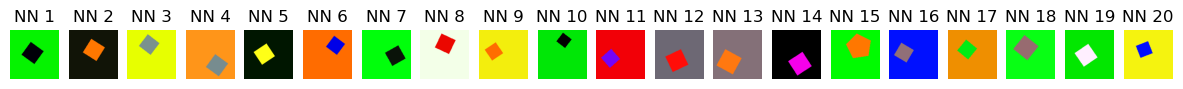

Prototype 66:
- Weight: 0.007993163540959358
- y value: 0.3226180374622345
- nn_bound_circle_r_avg: 33.5
- nn_bound_circle_r_std: 2.924038303442689


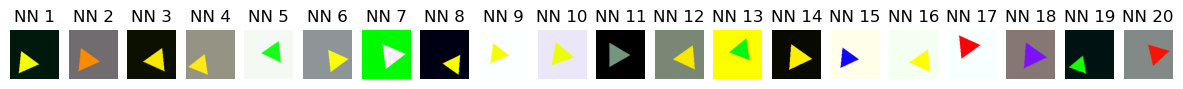

Prototype 75:
- Weight: 0.008603651076555252
- y value: 0.9980512857437134
- nn_bound_circle_r_avg: 60.4
- nn_bound_circle_r_std: 4.054626986542659


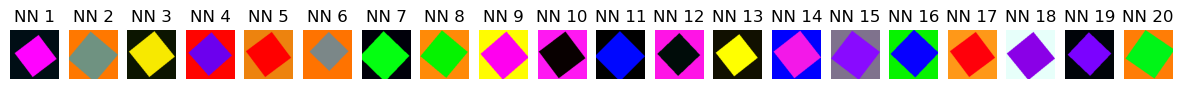

Prototype 84:
- Weight: 0.008270501159131527
- y value: 0.9976263642311096
- nn_bound_circle_r_avg: 58.75
- nn_bound_circle_r_std: 3.897114317029974


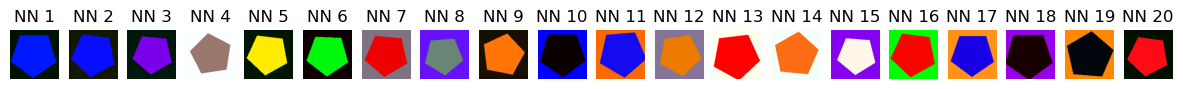

Prototype 93:
- Weight: 0.0076486701145768166
- y value: 0.8930659294128418
- nn_bound_circle_r_avg: 44.45
- nn_bound_circle_r_std: 3.707762128292483


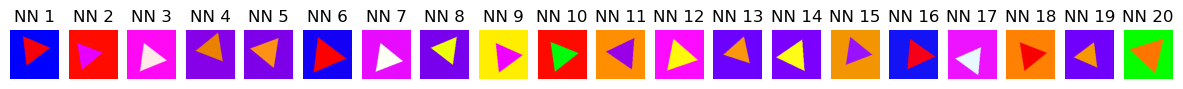

Prototype 102:
- Weight: 0.008947702124714851
- y value: 0.013995464891195297
- nn_bound_circle_r_avg: 13.25
- nn_bound_circle_r_std: 2.2555487137279924


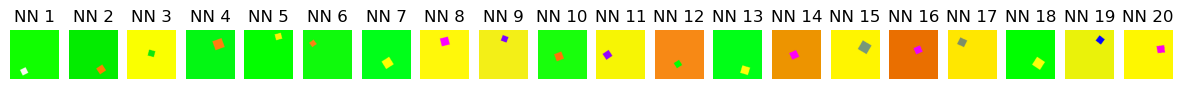

Prototype 110:
- Weight: 0.00780439842492342
- y value: 0.13661015033721924
- nn_bound_circle_r_avg: 25.85
- nn_bound_circle_r_std: 4.162631379308046


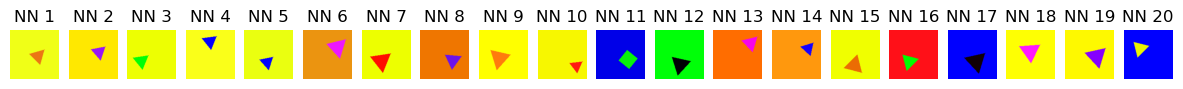

Prototype 117:
- Weight: 0.008231231942772865
- y value: 0.010912158526480198
- nn_bound_circle_r_avg: 15.4
- nn_bound_circle_r_std: 2.90516780926679


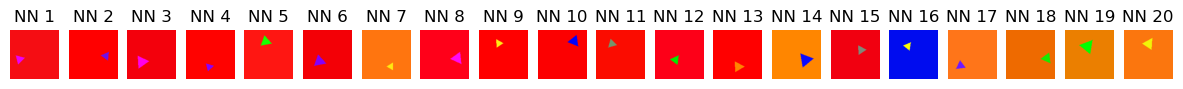

Prototype 126:
- Weight: 0.00802224688231945
- y value: 0.5916785597801208
- nn_bound_circle_r_avg: 36.8
- nn_bound_circle_r_std: 3.1874754901018454


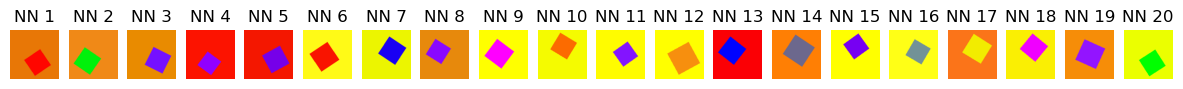

In [436]:
def plot_prototype_info(prototypes_df, train_df_encoded, images_path, prot_idx):
    """
    Prints information about a prototype and displays its nearest neighbor images.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype information.
        train_df_encoded (pd.DataFrame): DataFrame containing encoded training data.
        images_path (str): Path to the folder containing the images.
        prot_idx (int): Index of the prototype to visualize.
    """
    # Print the weight and y value for the specified prototype
    print(f"Prototype {prot_idx}:")
    print(f"- Weight: {prototypes_df['w'][prot_idx]}")
    print(f"- y value: {prototypes_df['y'][prot_idx]}")
    print(f"- nn_bound_circle_r_avg: {prototypes_df['nn_bound_circle_r_avg'][prot_idx]}")
    print(f"- nn_bound_circle_r_std: {prototypes_df['nn_bound_circle_r_std'][prot_idx]}")

    # Show the NN images
    nn_indices = prototypes_df['nn_indices'][prot_idx]

    plt.figure(figsize=(15, 5))  # Adjust figure size as needed

    for i, img_idx in enumerate(nn_indices):
        img_path = images_path + "/" + train_df_encoded['filename'][img_idx]
        img = plt.imread(img_path)
        plt.subplot(1, len(nn_indices), i + 1)
        plt.imshow(img)
        plt.title(f"NN {i+1}")
        plt.axis('off')
    plt.show()


idxs = prototypes_df_top.index.values
for i in range(0, len(idxs), 5):
    plot_prototype_info(prototypes_df_top, train_df_encoded, images_path, idxs[i])

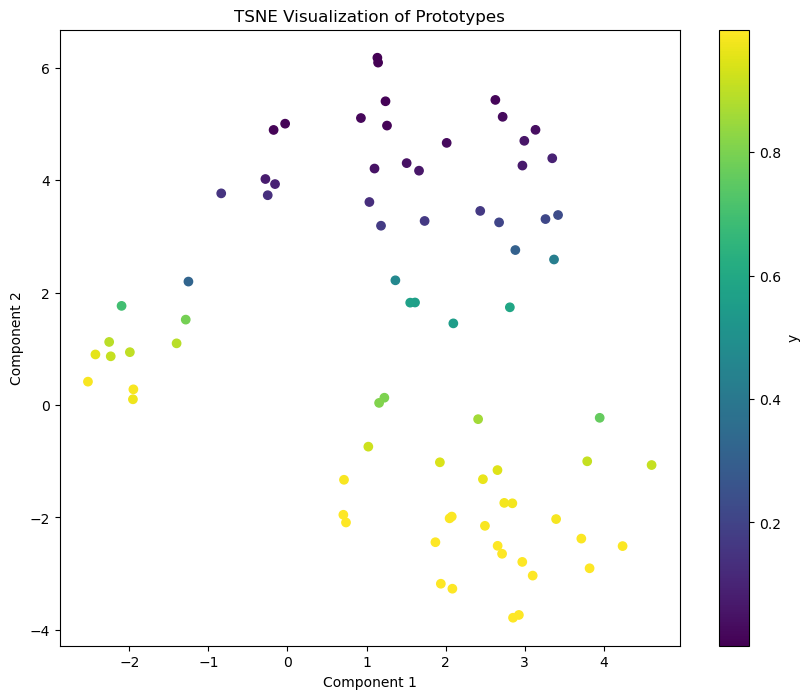

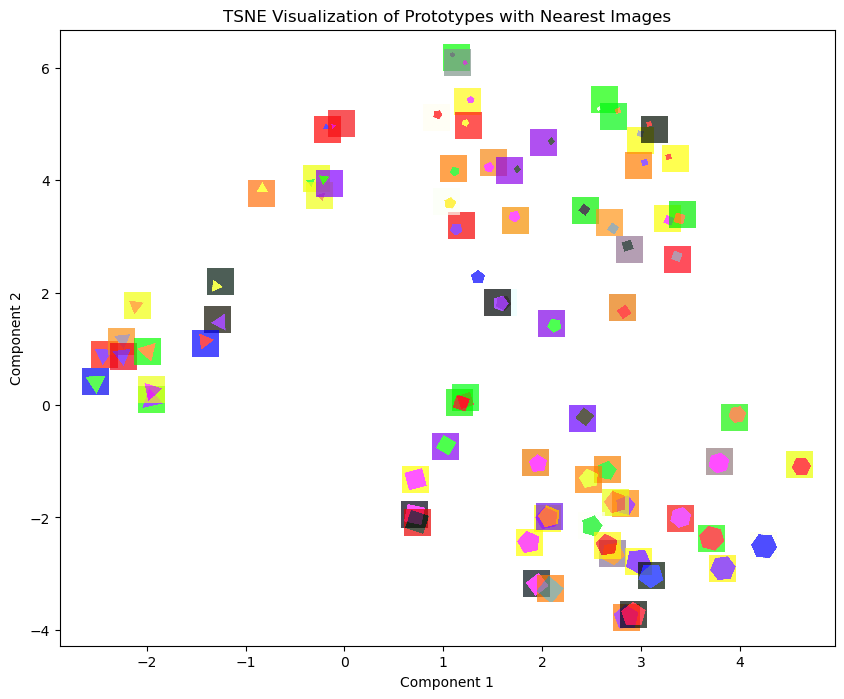

In [437]:
# prompt: Create a function that given a DF with prototypes create a 2-D visualization using t-sne

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, MDS, Isomap, LocallyLinearEmbedding

def visualize_prototypes(prototypes_df, embed_class):
    """
    Creates a 2-D visualization of prototypes using t-SNE.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype data,
            with a column 'x' representing the prototype encodings.
    """

    # Extract prototype encodings
    encodings = np.array(prototypes_df['x'].to_list())

    # Apply t-SNE
    # tsne = TSNE(n_components=2, random_state=42)  # You can adjust parameters here
    # embeddings = tsne.fit_transform(encodings)

    # apply MDS
    # mds = MDS(n_components=2, random_state=42)
    # embeddings = mds.fit_transform(encodings)

    # Apply Isomap
    embed_obj = embed_class(n_components=2)
    embeddings = embed_obj.fit_transform(encodings)

    # Apply LLE
    # lle = LocallyLinearEmbedding(n_components=2, random_state=41)
    # embeddings = lle.fit_transform(encodings)

    # Create the plot
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings[:, 0], embeddings[:, 1], c=prototypes_df['y'], cmap='viridis')
    plt.colorbar(label='y')
    plt.title(f'{embed_class.__name__} Visualization of Prototypes')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def visualize_prototypes_img(prototypes_df, train_df_encoded, images_path, embed_class):
    """
    Creates a 2-D visualization of prototypes using Isomap and displays closest images.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype data.
        train_df_encoded (pd.DataFrame): DataFrame with encoded training data and filenames.
        images_path (str): Path to image directory.
    """

    encodings = np.array(prototypes_df['x'].to_list())

    embed_obj = embed_class(n_components=2)
    embeddings = embed_obj.fit_transform(encodings)

    # Apply LLE
    # lle = LocallyLinearEmbedding(n_components=2, random_state=41)
    # embeddings = lle.fit_transform(encodings)


    indexes = prototypes_df.index.values

    fig, ax = plt.subplots(figsize=(10, 8))  # Create a single figure and axes
    ax.scatter(embeddings[:, 0], embeddings[:, 1], c=prototypes_df['y'], cmap='viridis', s=0)

    for i, embedding in enumerate(embeddings):
        nn_indices = prototypes_df['nn_indices'][indexes[i]]
        closest_image_idx = nn_indices[0]
        img_path = os.path.join(images_path, train_df_encoded['filename'][closest_image_idx])
        try:
            img = plt.imread(img_path)
            # Create an OffsetImage for each image
            imagebox = OffsetImage(img, zoom=0.15, alpha=0.7)  # Adjust zoom as needed
            ab = AnnotationBbox(imagebox, embedding, frameon=False)
            ax.add_artist(ab)
        except FileNotFoundError:
            print(f"Image not found at: {img_path}")

    plt.title(f'{embed_class.__name__} Visualization of Prototypes with Nearest Images')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()  # Display the plot after adding all images

visualize_prototypes(prototypes_df_top, TSNE)
visualize_prototypes_img(prototypes_df_top, train_df_encoded, images_path, TSNE)


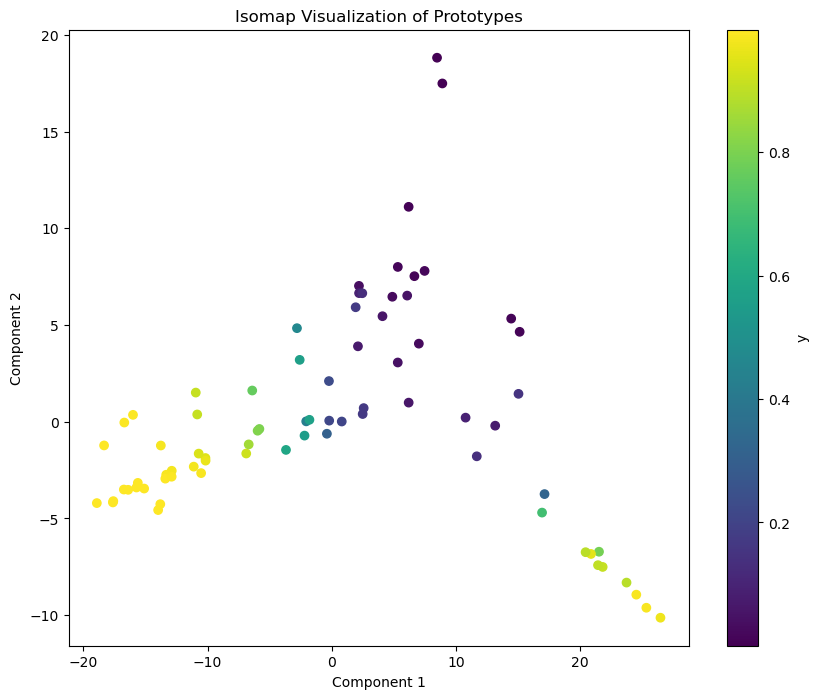

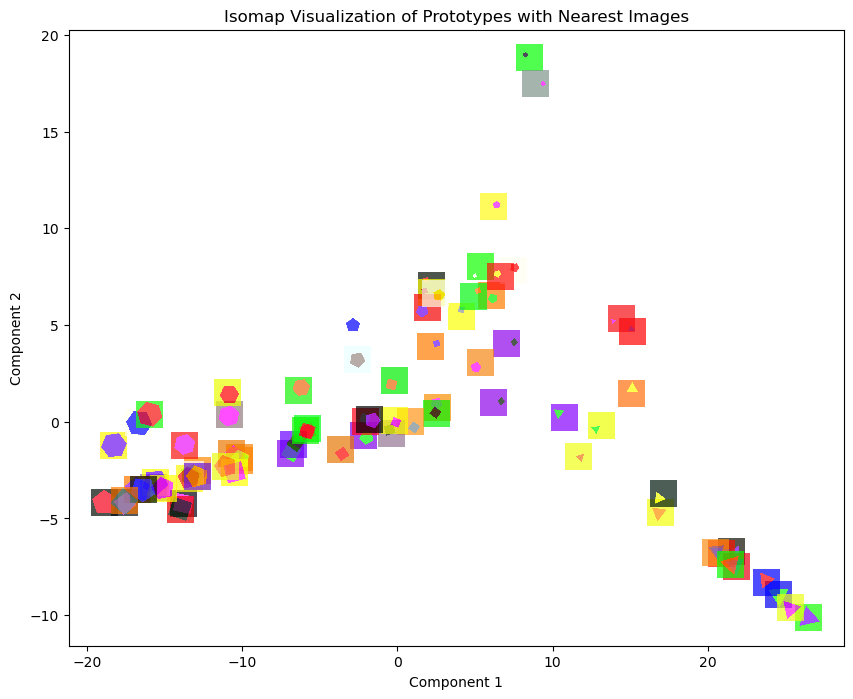

In [438]:
visualize_prototypes(prototypes_df_top, Isomap)
visualize_prototypes_img(prototypes_df_top, train_df_encoded, images_path, Isomap)


In [439]:
y_pred, y_var = kdm_gen_adj.predict_reg(test_ds)

# Create a copy of train_df
test_df_pred = test_df.copy()

#reset indices
test_df_pred.reset_index(drop=True, inplace=True)

# Add the encoding vector as a new column
test_df_pred['y_pred'] = y_pred.tolist()
test_df_pred['y_var'] = y_var.tolist()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


2025-02-15 15:20:45.053446: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [440]:
from kdm.utils import dm2comp, dm_rbf_loglik

def img_pred_plot(img):
    image = transform_image(img)
    image = image.to(device)
    with torch.no_grad():
        outputs = dinov2_vits14(image[None, ...])
        img_emb = outputs.cpu().detach().numpy()
    x = np.atleast_2d(np.linspace(0, 1, 1000)).T
    rho_y = keras.ops.cast(kdm_gen_adj.predict(img_emb), dtype='float32')
    y_pred, y_var = kdm_gen_adj.predict_reg(img_emb)
    print(f'y_pred: {y_pred}, y_var: {y_var}')
    sigma_y = keras.ops.clip(kdm_gen_adj.sigma_y, kdm_gen_adj.min_sigma_y, np.inf)
    loglik = dm_rbf_loglik(keras.ops.convert_to_tensor(x, dtype="float32"),rho_y,sigma_y)
    lik = keras.ops.convert_to_numpy(keras.ops.exp(loglik))

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.plot(x, lik)
    plt.xlabel('y')
    plt.ylabel('Probability density')
    plt.ylim(0, 5)
    plt.title("Predicted PDF")
    w, v = dm2comp(rho_y)
    w = keras.ops.convert_to_numpy(w)
    v = keras.ops.convert_to_numpy(v)
    idx_sort = np.argsort(-w[0])
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(len(w[0])), w[0])
    plt.xlabel('idx')
    plt.ylabel('Prototype Weight')
    plt.title("Weight")
    plt.show()
    plt.figure(figsize=(12.5, 1.5))  # Adjust figure size as needed
    for i in range(5):
        nn_indices = prototypes_df['nn_indices'][idx_sort[i]]
        closest_image_idx = nn_indices[0]
        img_path = os.path.join(images_path, train_df_encoded['filename'][closest_image_idx])
        try:
            plt.subplot(1, 5, i + 1)
            img = plt.imread(img_path)
            plt.imshow(img)
            plt.title(f"W: {w[0, idx_sort[i]]:.3f} y:{v[0, idx_sort[i], 0]:.3f}",
                      fontsize=8)
            plt.axis('off')
        except FileNotFoundError:
            print(f"Image not found at: {img_path}")
    plt.show()






Index: 930 y_pred: [0.505085825920105], y_var: 0.1411941796541214, label: 1.0


<Figure size 500x300 with 0 Axes>

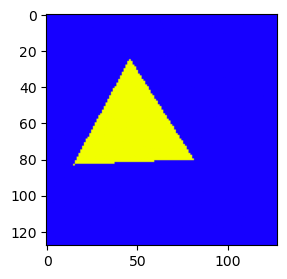

/Users/fgonza/miniforge3/envs/tf2/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.5050853]], y_var: [0.14119421]


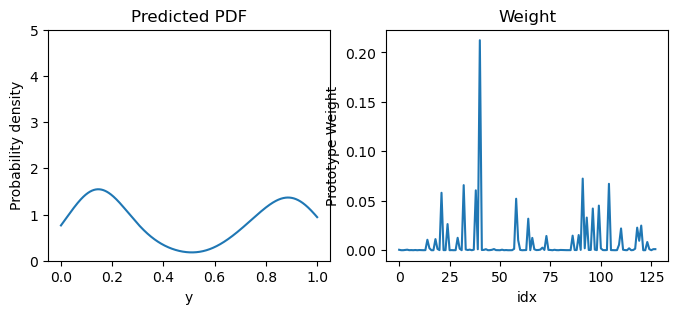

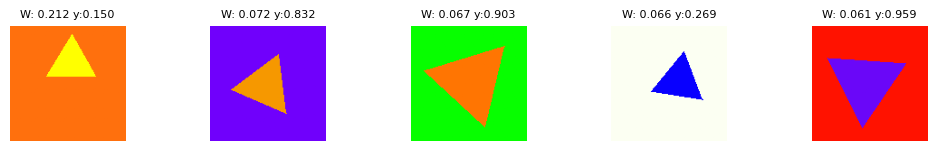



Index: 1840 y_pred: [0.577073872089386], y_var: 0.1380009800195694, label: 1.0


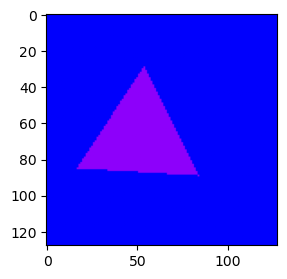

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.57707465]], y_var: [0.13800098]


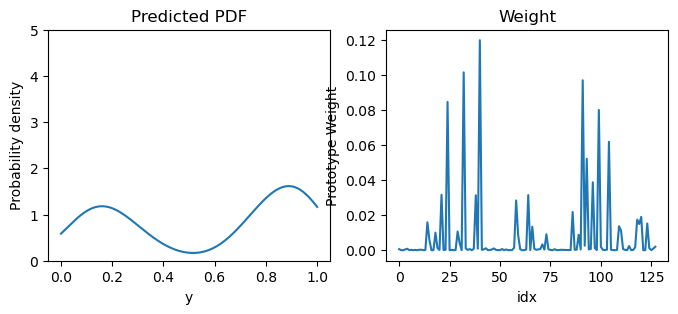

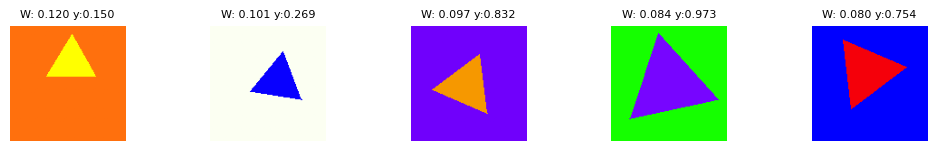



Index: 1424 y_pred: [0.5329896211624146], y_var: 0.13770775496959686, label: 1.0


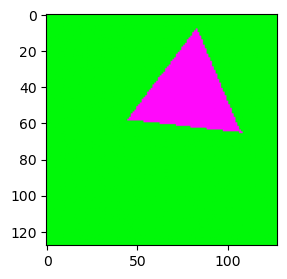

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.53299105]], y_var: [0.13770775]


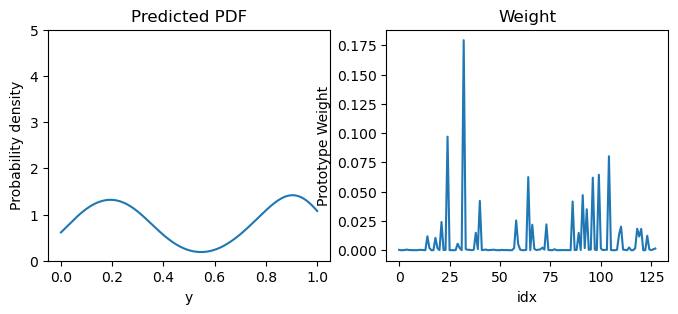

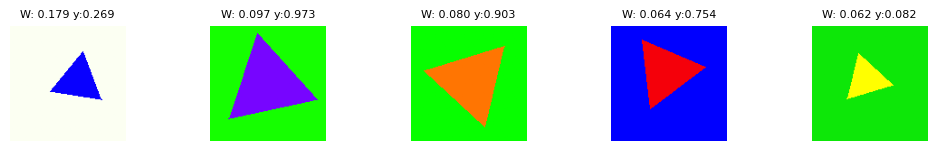



Index: 91 y_pred: [0.46850061416625977], y_var: 0.13580749928951263, label: 1.0


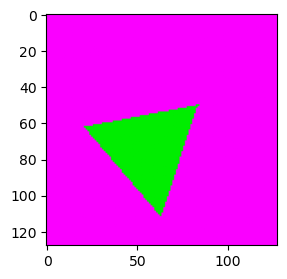

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.46849903]], y_var: [0.13580734]


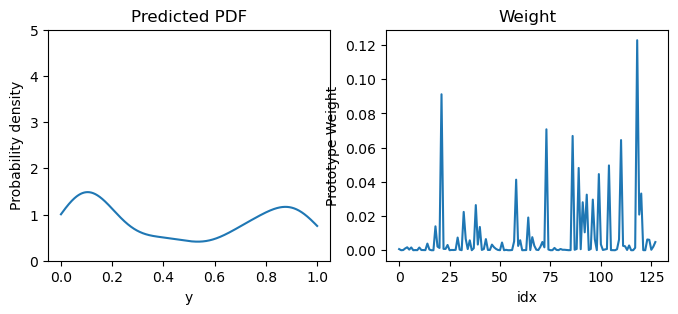

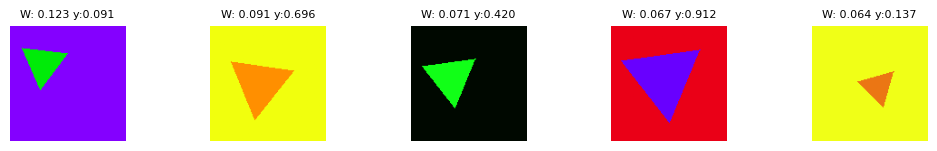



Index: 349 y_pred: [0.6294717788696289], y_var: 0.13527531921863556, label: 1.0


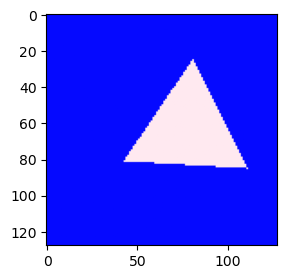

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.6294723]], y_var: [0.13527523]


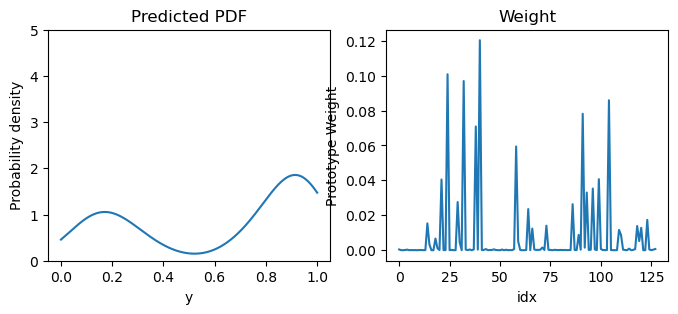

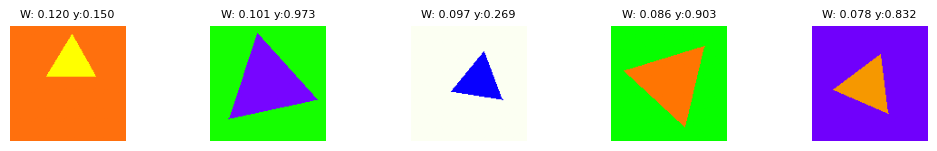



Index: 130 y_pred: [0.44029104709625244], y_var: 0.13360698521137238, label: 1.0


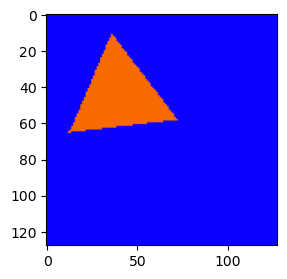

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.4402911]], y_var: [0.13360712]


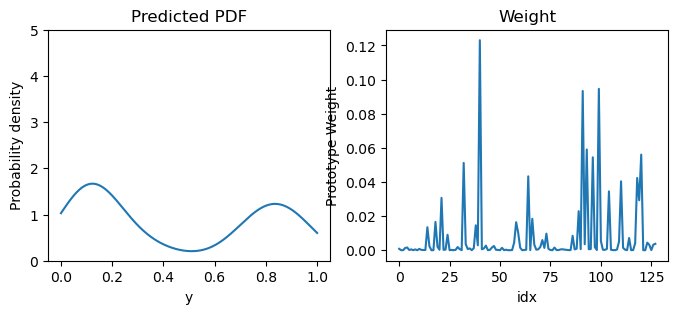

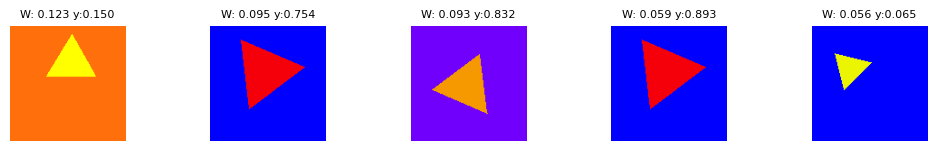



Index: 451 y_pred: [0.522650420665741], y_var: 0.13342635333538055, label: 1.0


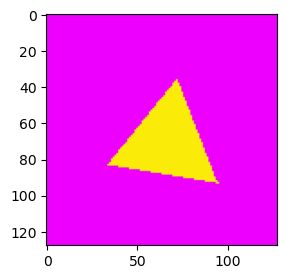

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.5226493]], y_var: [0.13342635]


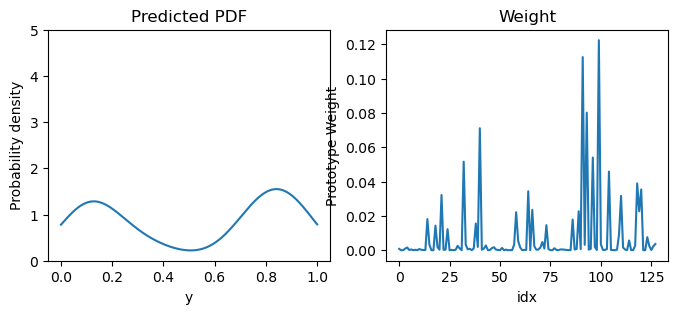

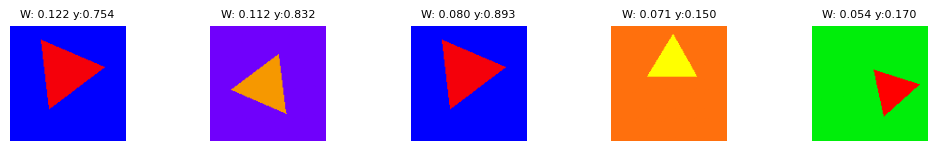



Index: 919 y_pred: [0.4416605830192566], y_var: 0.13330750167369843, label: 1.0


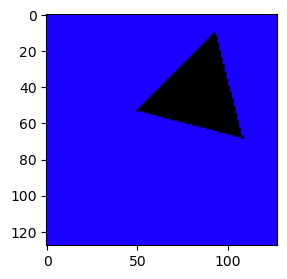

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.44166115]], y_var: [0.13330738]


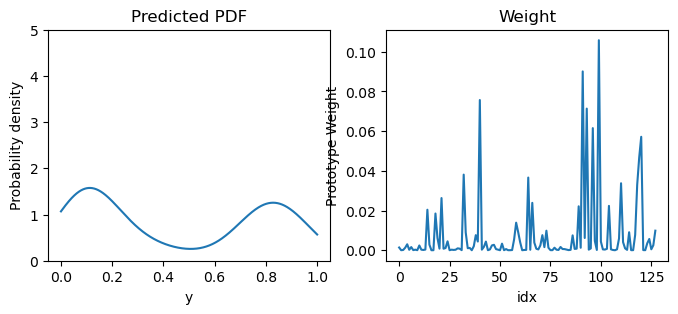

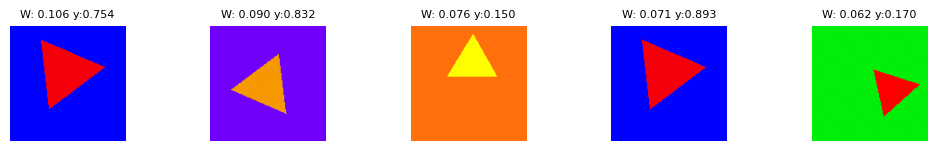



Index: 1228 y_pred: [0.5498386025428772], y_var: 0.13212324678897858, label: 1.0


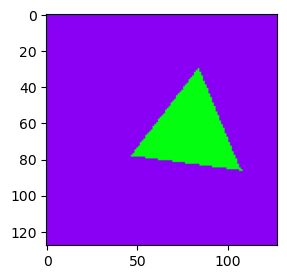

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
y_pred: [[0.54983795]], y_var: [0.13212316]


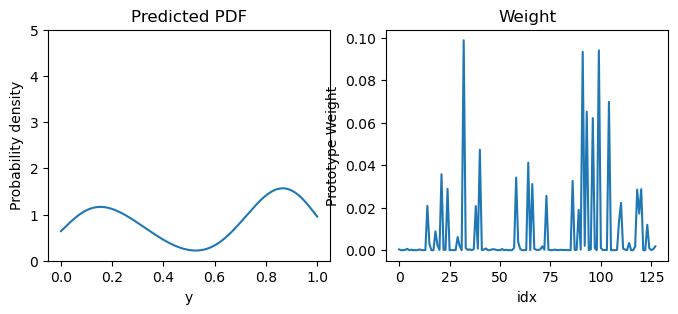

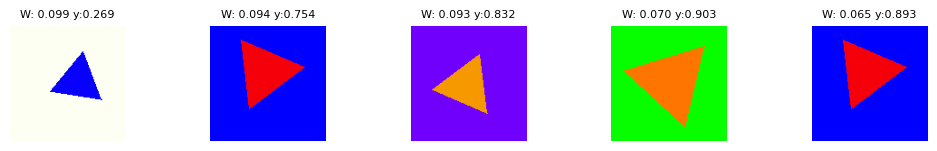



Index: 1518 y_pred: [0.591291606426239], y_var: 0.12979157269001007, label: 1.0


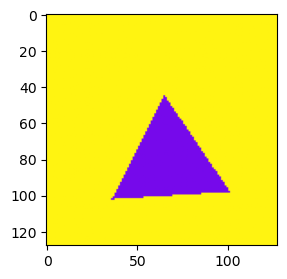

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.5912912]], y_var: [0.12979163]


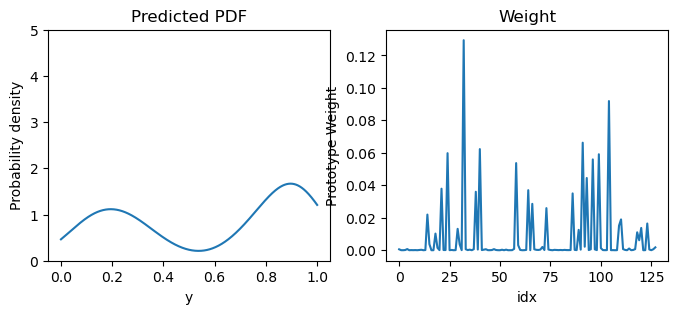

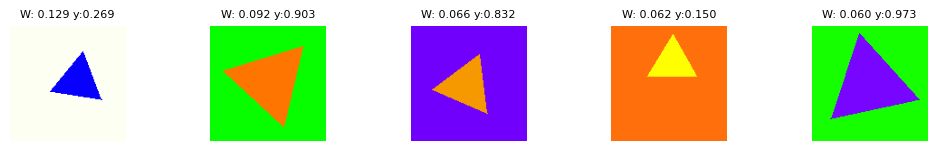



Index: 585 y_pred: [0.40929049253463745], y_var: 0.12886525690555573, label: 1.0


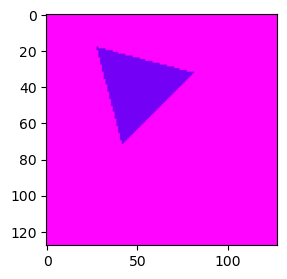

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.40928966]], y_var: [0.12886517]


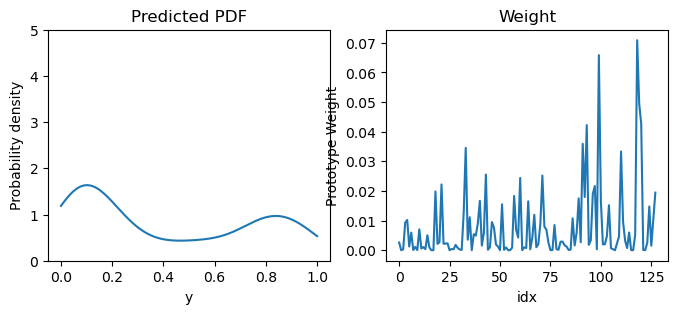

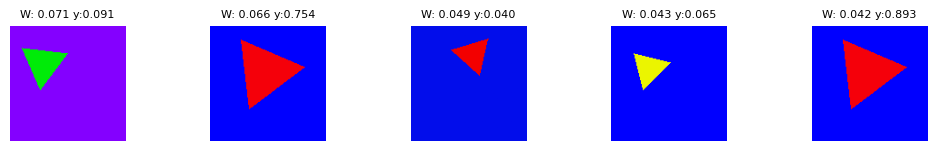



Index: 1923 y_pred: [0.5177608132362366], y_var: 0.12848414480686188, label: 1.0


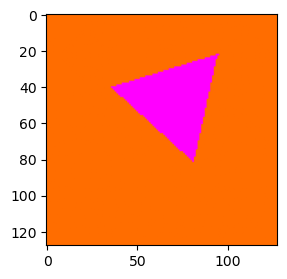

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.5177603]], y_var: [0.12848417]


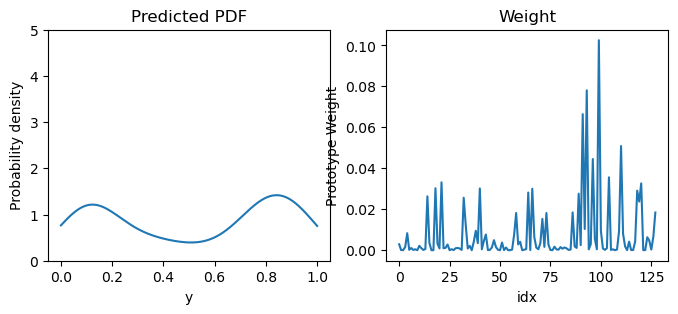

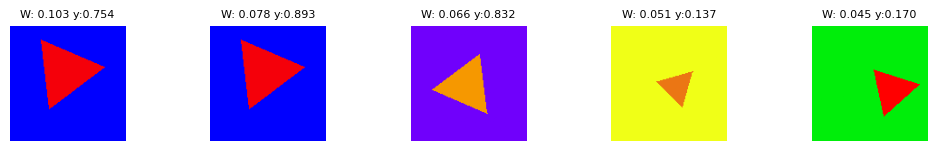



Index: 1136 y_pred: [0.3754274547100067], y_var: 0.12779268622398376, label: 1.0


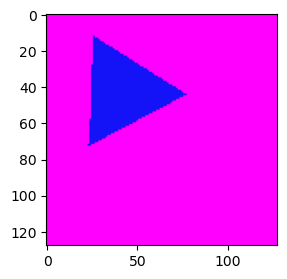

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.37542683]], y_var: [0.12779269]


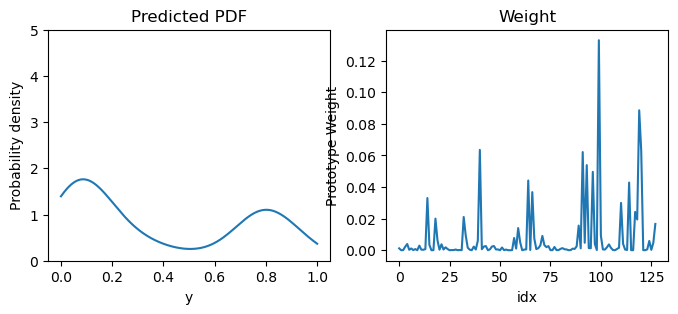

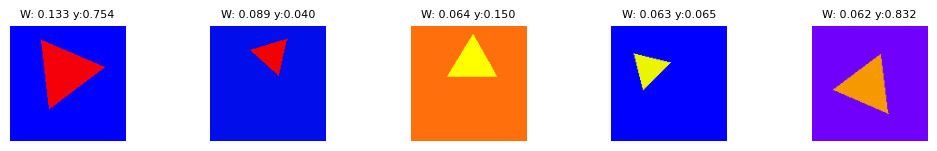



Index: 340 y_pred: [0.5388884544372559], y_var: 0.12764208018779755, label: 1.0


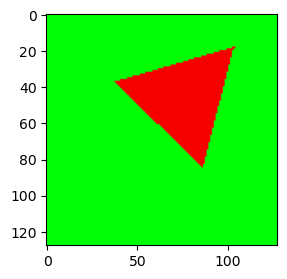

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.53888834]], y_var: [0.12764223]


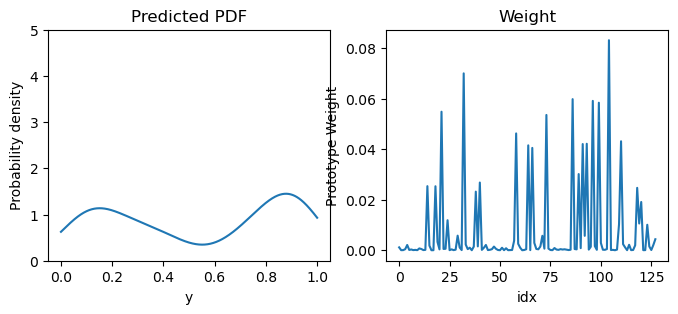

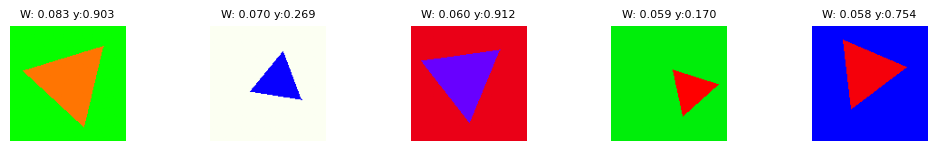



Index: 1374 y_pred: [0.39323118329048157], y_var: 0.12741795182228088, label: 1.0


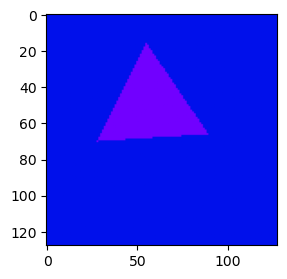

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.3932321]], y_var: [0.12741809]


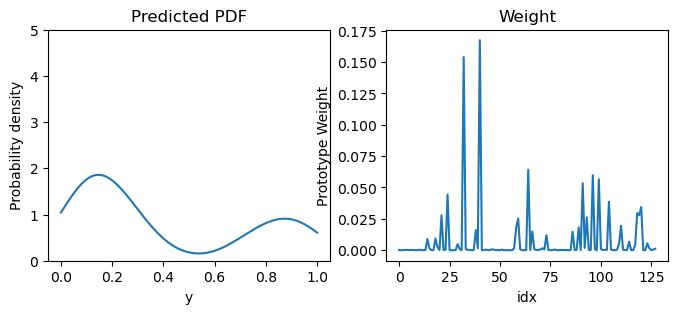

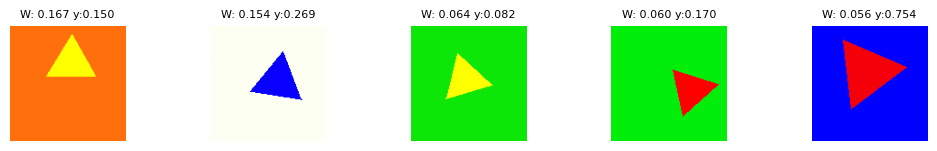



Index: 1246 y_pred: [0.4911768138408661], y_var: 0.127020463347435, label: 1.0


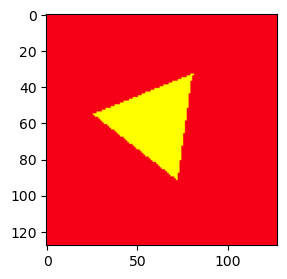

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.49117655]], y_var: [0.12702045]


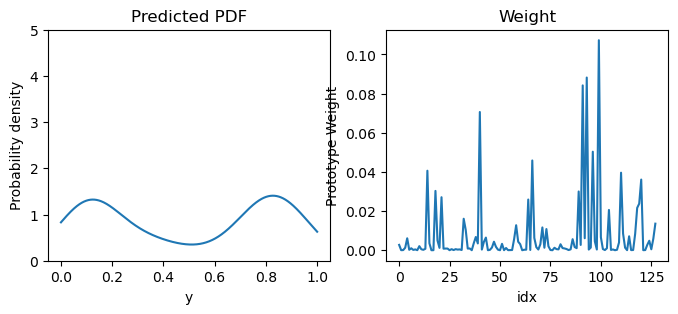

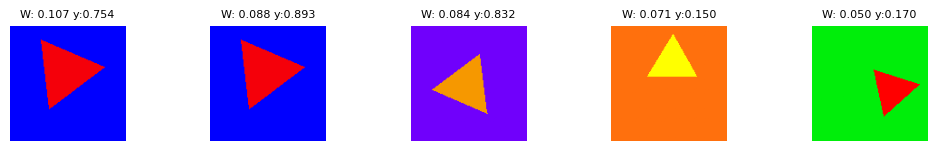



Index: 469 y_pred: [0.502922773361206], y_var: 0.12652866542339325, label: 1.0


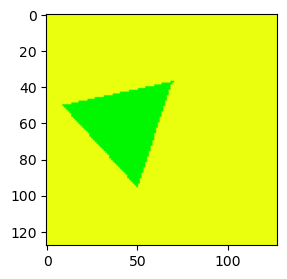

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.5029233]], y_var: [0.1265286]


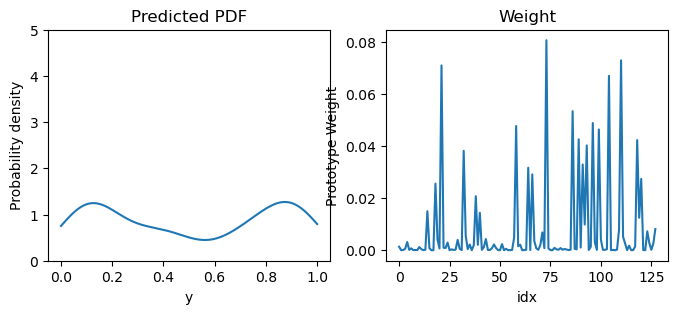

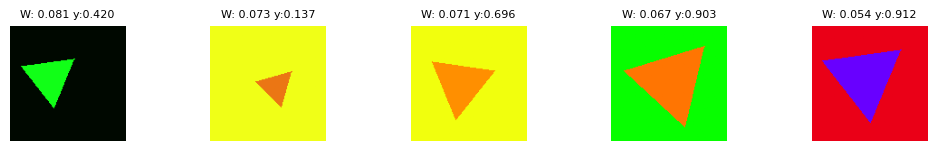



Index: 42 y_pred: [0.4377105236053467], y_var: 0.1262836754322052, label: 1.0


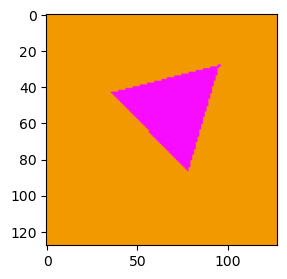

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.43770924]], y_var: [0.12628366]


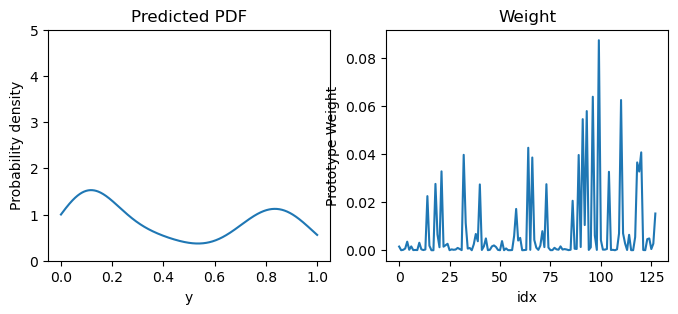

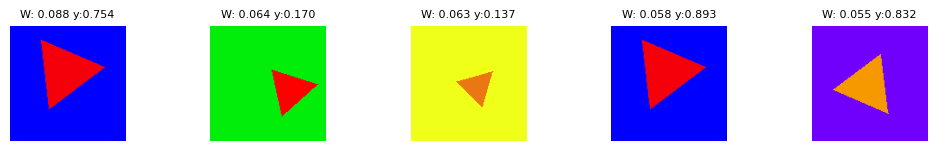



Index: 619 y_pred: [0.4946291148662567], y_var: 0.12617217004299164, label: 1.0


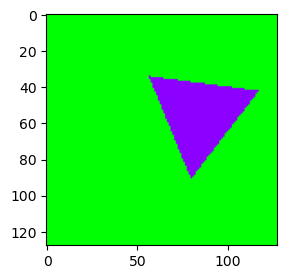

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.49462998]], y_var: [0.1261724]


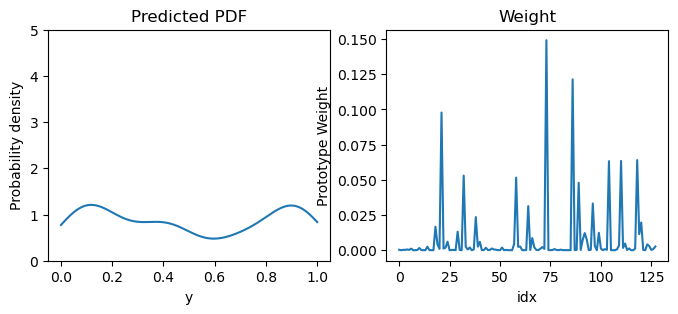

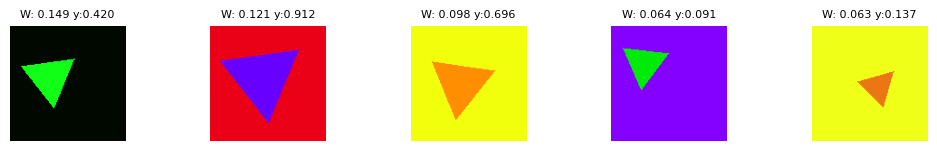



Index: 557 y_pred: [0.40345990657806396], y_var: 0.12544138729572296, label: 1.0


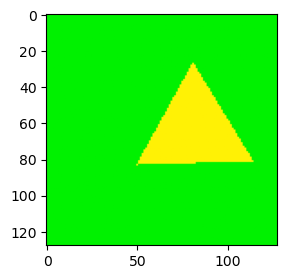

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.40345943]], y_var: [0.12544124]


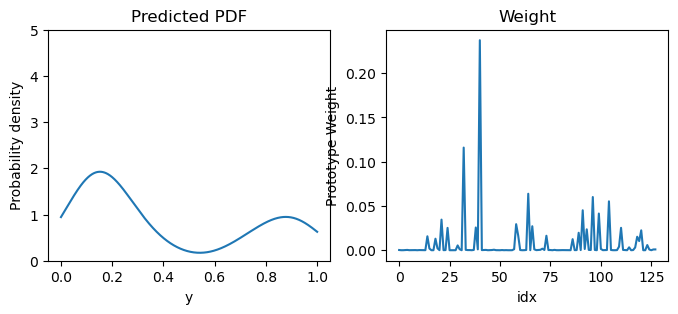

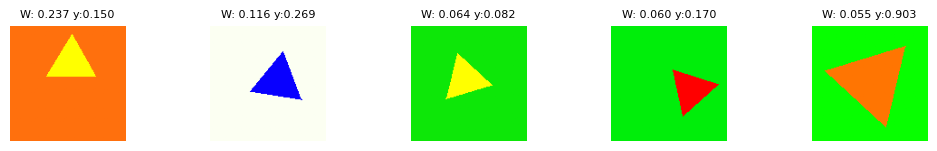



Index: 1751 y_pred: [0.6251021027565002], y_var: 0.1252242475748062, label: 1.0


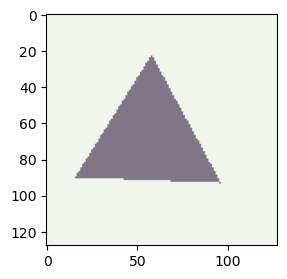

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.62510294]], y_var: [0.12522428]


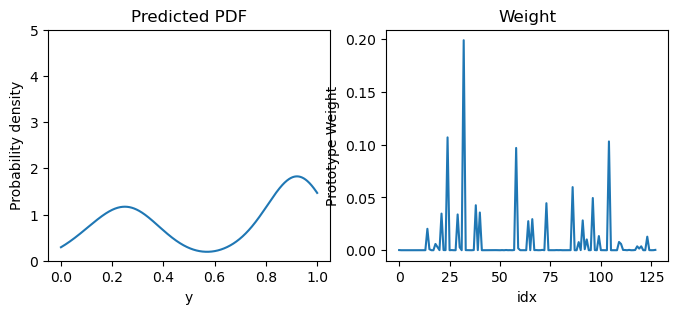

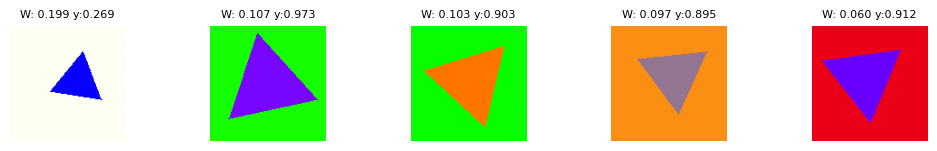



Index: 202 y_pred: [0.6050220131874084], y_var: 0.12503470480442047, label: 1.0


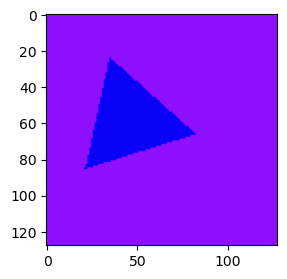

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.6050226]], y_var: [0.12503453]


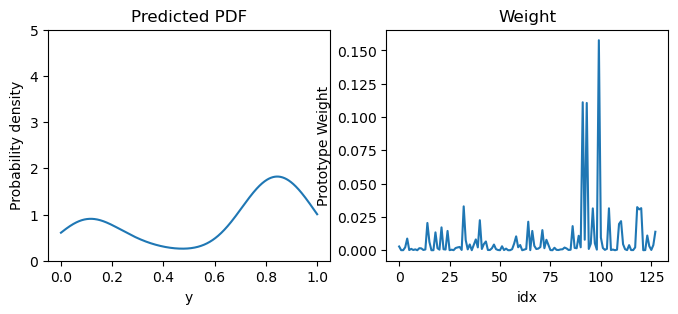

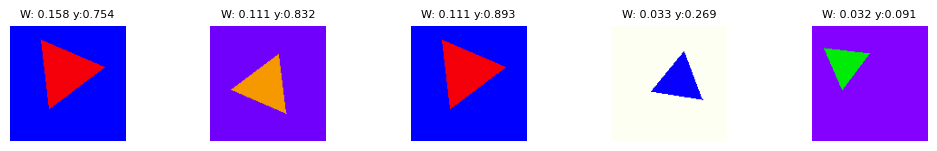



Index: 1771 y_pred: [0.4380905032157898], y_var: 0.12478797137737274, label: 1.0


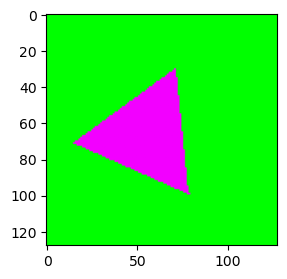

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.43809026]], y_var: [0.12478785]


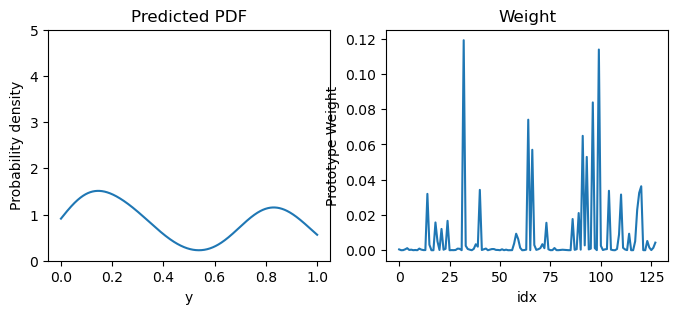

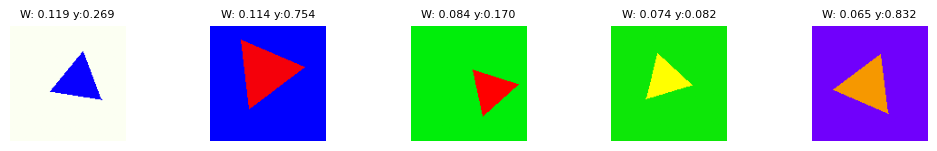



Index: 1049 y_pred: [0.5183603763580322], y_var: 0.12424351274967194, label: 1.0


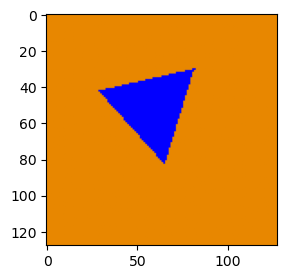

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.51836085]], y_var: [0.12424348]


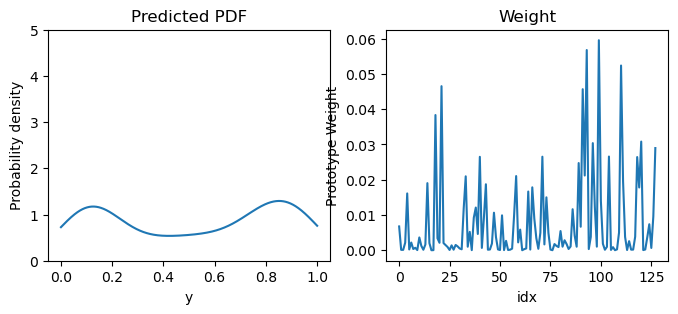

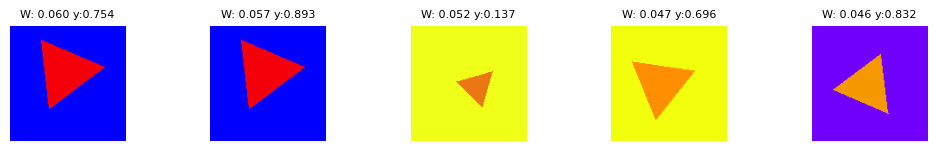



Index: 1744 y_pred: [0.3739854097366333], y_var: 0.12290528416633606, label: 1.0


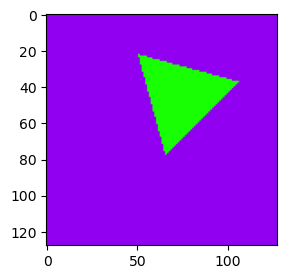

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.3739857]], y_var: [0.12290542]


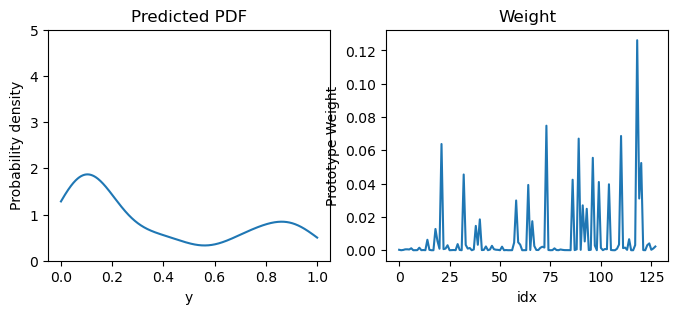

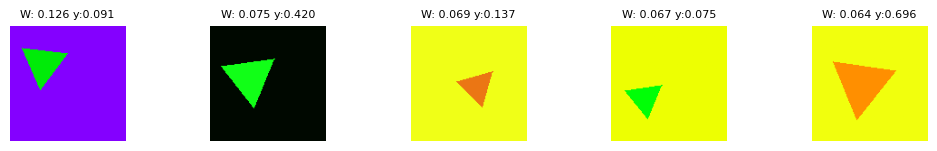



Index: 429 y_pred: [0.512532651424408], y_var: 0.12195675075054169, label: 1.0


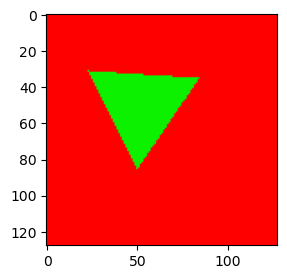

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.5125332]], y_var: [0.1219566]


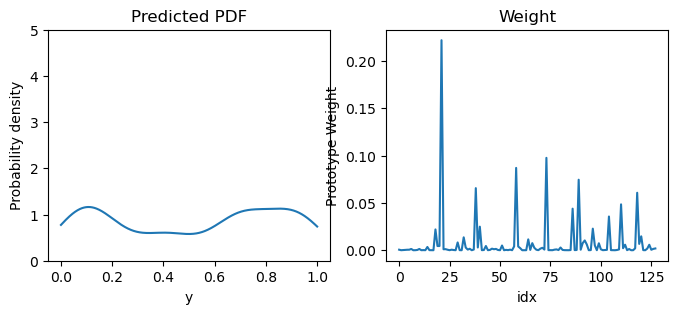

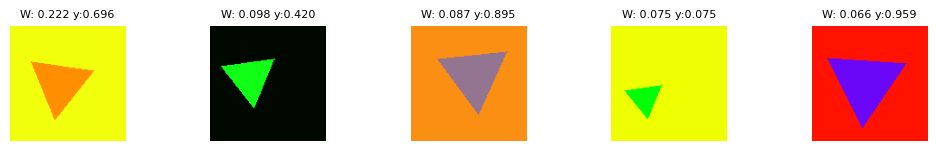



Index: 553 y_pred: [0.5931045413017273], y_var: 0.12157042324542999, label: 1.0


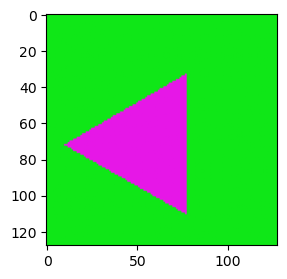

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.59310424]], y_var: [0.12157075]


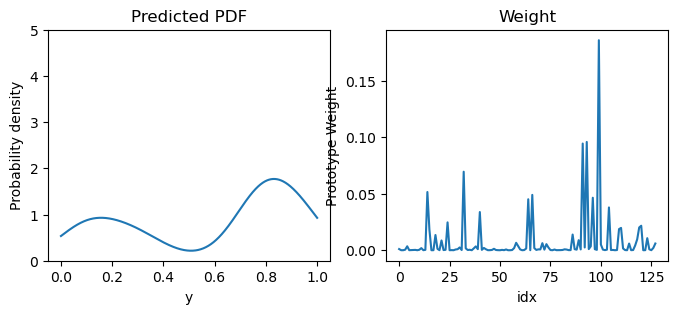

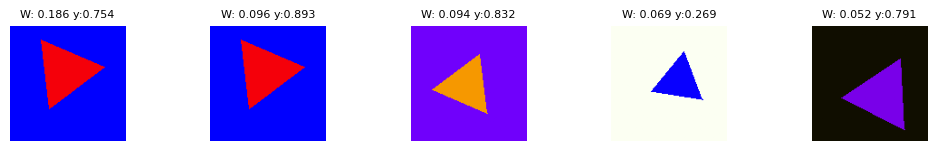



Index: 14 y_pred: [0.35499870777130127], y_var: 0.12149845063686371, label: 1.0


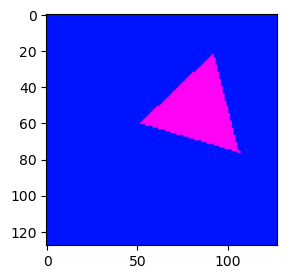

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.35499856]], y_var: [0.12149848]


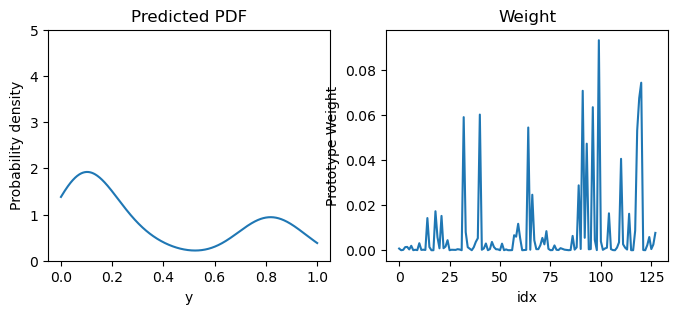

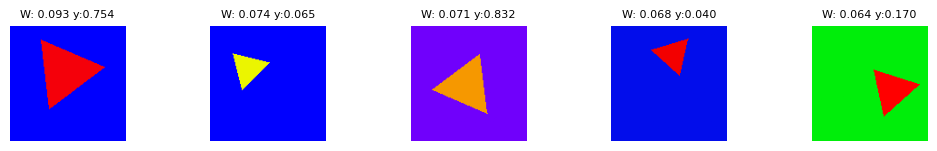



Index: 1321 y_pred: [0.5680569410324097], y_var: 0.12146724760532379, label: 1.0


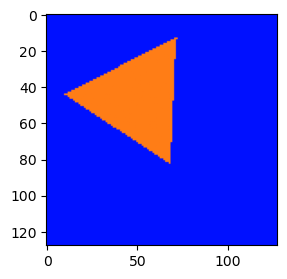

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.56805664]], y_var: [0.12146731]


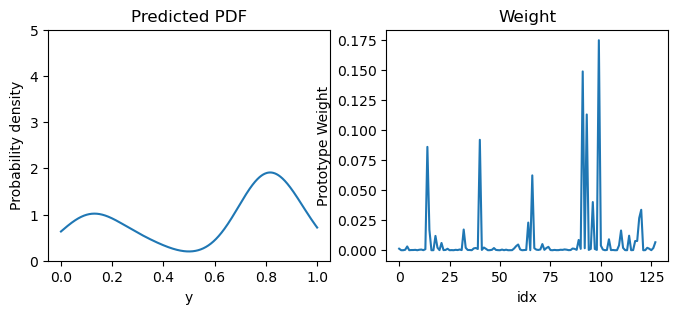

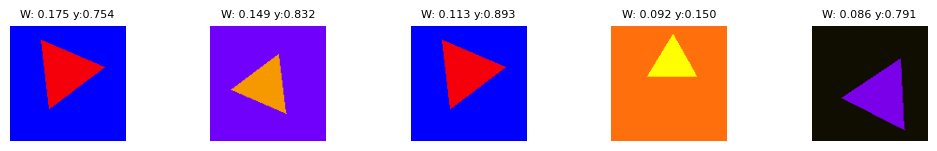



Index: 1656 y_pred: [0.3829280138015747], y_var: 0.119460329413414, label: 1.0


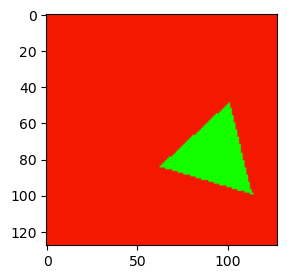

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred: [[0.38292772]], y_var: [0.11946031]


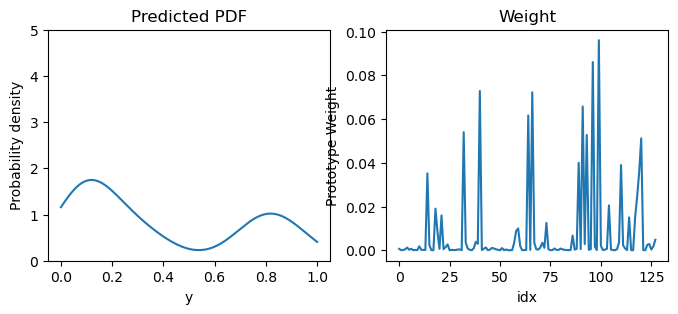

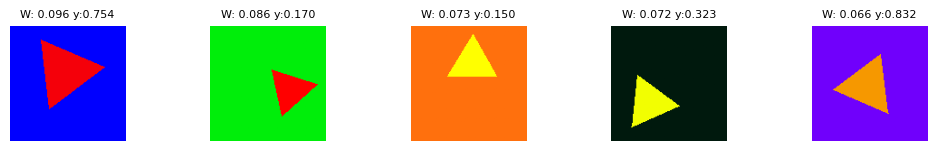

<Figure size 640x480 with 0 Axes>

In [441]:
# prompt: Get the top n images from test_df_pred with largest y_var

# Assuming test_df_pred is defined and contains 'y_var' and 'filename' columns.
# Also assuming images_path is defined.

import matplotlib.pyplot as plt
import os

# Sort test_df_pred by y_var in descending order and get the top n
n = 30
top_n_images = test_df_pred.sort_values('y_var', ascending=False).head(n)

# Display the top n images
plt.figure(figsize=(5, 3))  # Adjust figure size as needed

for i, (index, row) in enumerate(top_n_images.iterrows()):
    img_path = os.path.join(images_path, row['filename'])
    try:
        label = (row['bound_circle_r'] >= 0.5) * 1.
        print(f'\n\nIndex: {index} y_pred: {row["y_pred"]}, y_var: {row["y_var"]}, label: {label}')
        plt.figure(figsize=(5, 3))  # Adjust figure size as needed
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.show()
        img_pred_plot(img)
    except FileNotFoundError:
        print(f"Image not found at: {img_path}")

plt.tight_layout()  # Adjust layout to prevent overlapping titles
plt.show()

In [442]:
encoder = create_encoder(input_shape=input_shape, layer_sizes=layer_sizes)
print(encoder.summary())
# warm up the encoder with a small subset
encoder_wmp = keras.Sequential([encoder,
                                keras.layers.Dense(256, activation='gelu'),
                                keras.layers.Dense(1, activation='sigmoid')])
encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                loss=losses.binary_crossentropy,
                metrics=[metrics.binary_accuracy])

# train the encoder for 2 epoch
subset_ds = train_ds
encoder_wmp.fit(subset_ds, epochs=5, verbose=1)

pred_nn = encoder_wmp.predict(test_ds)
test_df['pred_nn'] = pred_nn[:, 0]

pred_kdm_reg, var = kdm_gen_adj.predict_reg(test_ds)
test_df['pred_kdm_reg'] = pred_kdm_reg[:, 0]

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_170 (InputLayer)    │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 32)             │        12,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,320 (48.12 KB)

 Trainable params: 12,320 (48.12 KB)

 Non-trainable params: 0 (0.00 B)

...

2025-02-15 15:20:59.987881: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9007 - loss: 0.2298
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
22/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-02-15 15:21:00.605039: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-15 15:21:00.740031: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2025-02-15 15:21:00.893364: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


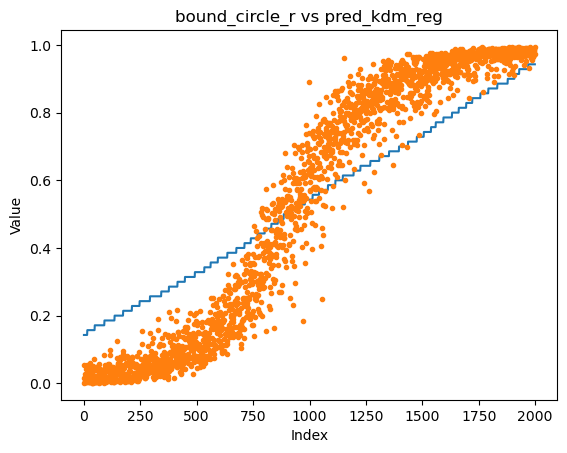

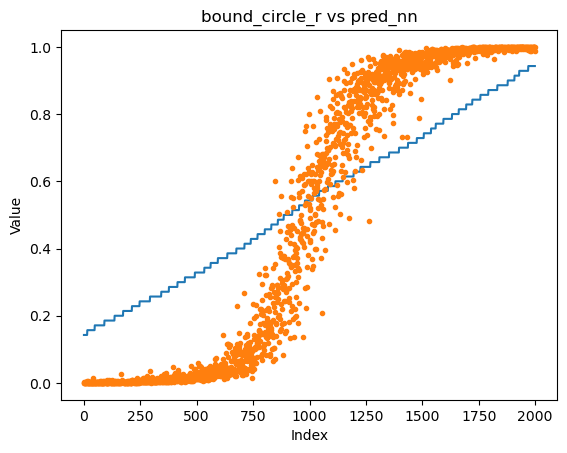

In [443]:
# prompt: Sort test_df by ' bound_circle_r' column

test_df_sorted = test_df.sort_values(by='bound_circle_r')

# plot values in 'bound_circle_r'
plt.plot(range(len(test_df_sorted)), test_df_sorted['bound_circle_r'] / 70)
plt.plot(range(len(test_df_sorted)), test_df_sorted['pred_kdm_reg'], '.')
plt.title('bound_circle_r vs pred_kdm_reg')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

plt.plot(range(len(test_df_sorted)), test_df_sorted['bound_circle_r'] / 70)
plt.plot(range(len(test_df_sorted)), test_df_sorted['pred_nn'], '.')
plt.title('bound_circle_r vs pred_nn')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()


